In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import subprocess
import os
from scipy.stats import chi2_contingency
from datetime import timedelta

from etl.customer import aggregate_customer
from etl.subsidy import report_customer_conversion_by_subsidy_issue_status, report_customer_metrics_by_subsidy_issue_status
from etl.subsidy import visualize_conversion_by_subsidy_issues, report_customer_subsidy_issues_by_product
from etl.subsidy import visualize_customer_subsidy_issues_by_product, visualize_policy_suspension_impact
from etl.price import visualize_conversion_by_price_sweet_spots, visualize_conversion_by_price_sweet_spots_variant
from etl.price import report_product_conversion_by_price_quartile, visualize_conversion_by_equipment_category_price
from etl.price import visualise_conversion_by_brand_price, show_two_panel_conversion_by_brand_price
from etl.price import visualize_conversion_by_equipment_type_brand_price, show_conversion_by_price_dashboard, show_product_type_price_conversion_heatmap
from etl.season import visualize_conversion_by_season, visualize_regional_seasonality
from etl.period import visualize_conversion_by_year, report_best_and_worst_months, show_conversion_by_price_over_time, overlay_all_years_on_one_plot
from etl.period import visualize_conversion_by_prices_sweet_spot_shift, visualize_decision_times, show_decision_time_dashboard
from etl.product import visualise_heat_pump_performance, show_product_type_by_brand_heatmap, show_product_type_by_agency_heatmap, show_brand_by_product_type_heatmap


import warnings
warnings.filterwarnings('ignore')

df_clean = pd.read_csv('cleaned_quote_data.csv')
df_clean['dt_creation_devis'] = pd.to_datetime(df_clean['dt_creation_devis'])
print(f"Loaded data: {len(df_clean):,} quotes from {df_clean['numero_compte'].nunique():,} customers")

Loaded data: 37,008 quotes from 25,716 customers


In [2]:
customers = aggregate_customer(df_clean)

Quote-level columns created:
  - out_of_pocket: 34,991 values
  - subsidy_issue: 9,076 issues (24.5%)
  - brand-product pairs: 146 unique combinations

BRAND-PRODUCT VALIDATION

❌ ATLANTIC + Stove customers (should be 0): 0
✅ FIXED: No ATLANTIC + Stove combinations found!

✅ Customer dataset created: 25,716 customers
✅ Total columns: 61
✅ Key columns now available:
   - main_brand: from brand-product pair (most common option)
   - main_equipment_category: from brand-product pair (most common option)
   - brand_product_nunique: 1.2 avg options per customer
   - shopped_around: 4,484 customers (17.4%)
   - decision_days: from customer_duration_days
   - price_cv: from std_out_of_pocket / avg_out_of_pocket
   - quote_count: alias for total_quotes
   - price_range: 1142 avg
   - price_volatility: 0.26 avg

Subsidy issue type distribution:
subsidy_issue_type
No Issues            18660
Both                  2480
CEE Only              2361
MaPrimeRénov Only     2215
Name: count, dtype: int64


In [3]:
all_customers = pd.read_csv('customer_master_data.csv')

In [4]:
# Using quarter column (if you have it)
customers_2025_q1 = all_customers[
    (all_customers['year'] == 2025) & 
    (all_customers['quarter'] == 1)
]

# Using date range
customers_2025_q1 = all_customers[
    (all_customers['first_quote_date'] >= '2025-01-01') & 
    (all_customers['first_quote_date'] <= '2025-03-31')
]

print(f"Q1 2025 customers: {len(customers_2025_q1):,}")

Q1 2025 customers: 2,503


In [5]:
customers = customers_2025_q1


Customer conversion by subsidy issue status:

                   conversion_rate  customer_count  converted_count
had_subsidy_issue                                                  
False                     0.378575            1923            728.0
True                      0.455172             580            264.0

Chi-square p-value: 1.124999e-03
Statistically significant: YES

Conversion without issues: 37.86%
Conversion with issues: 45.52%
Difference: 7.7 percentage points
Customer-level finding: +7.7 points

Customer characteristics by subsidy issue status

Metric comparison:

total_quotes:
  No issues: 1.39
  With issues: 1.53
  Ratio: 1.11x

avg_quote_amount:
  No issues: 6147.34
  With issues: 9288.33
  Ratio: 1.51x

max_quote_amount:
  No issues: 6546.66
  With issues: 10213.52
  Ratio: 1.56x

customer_duration_days:
  No issues: 14.63
  With issues: 19.80
  Ratio: 1.35x

price_range:
  No issues: 825.92
  With issues: 1730.74
  Ratio: 2.10x

multiple_quotes:
  No issues: 0.

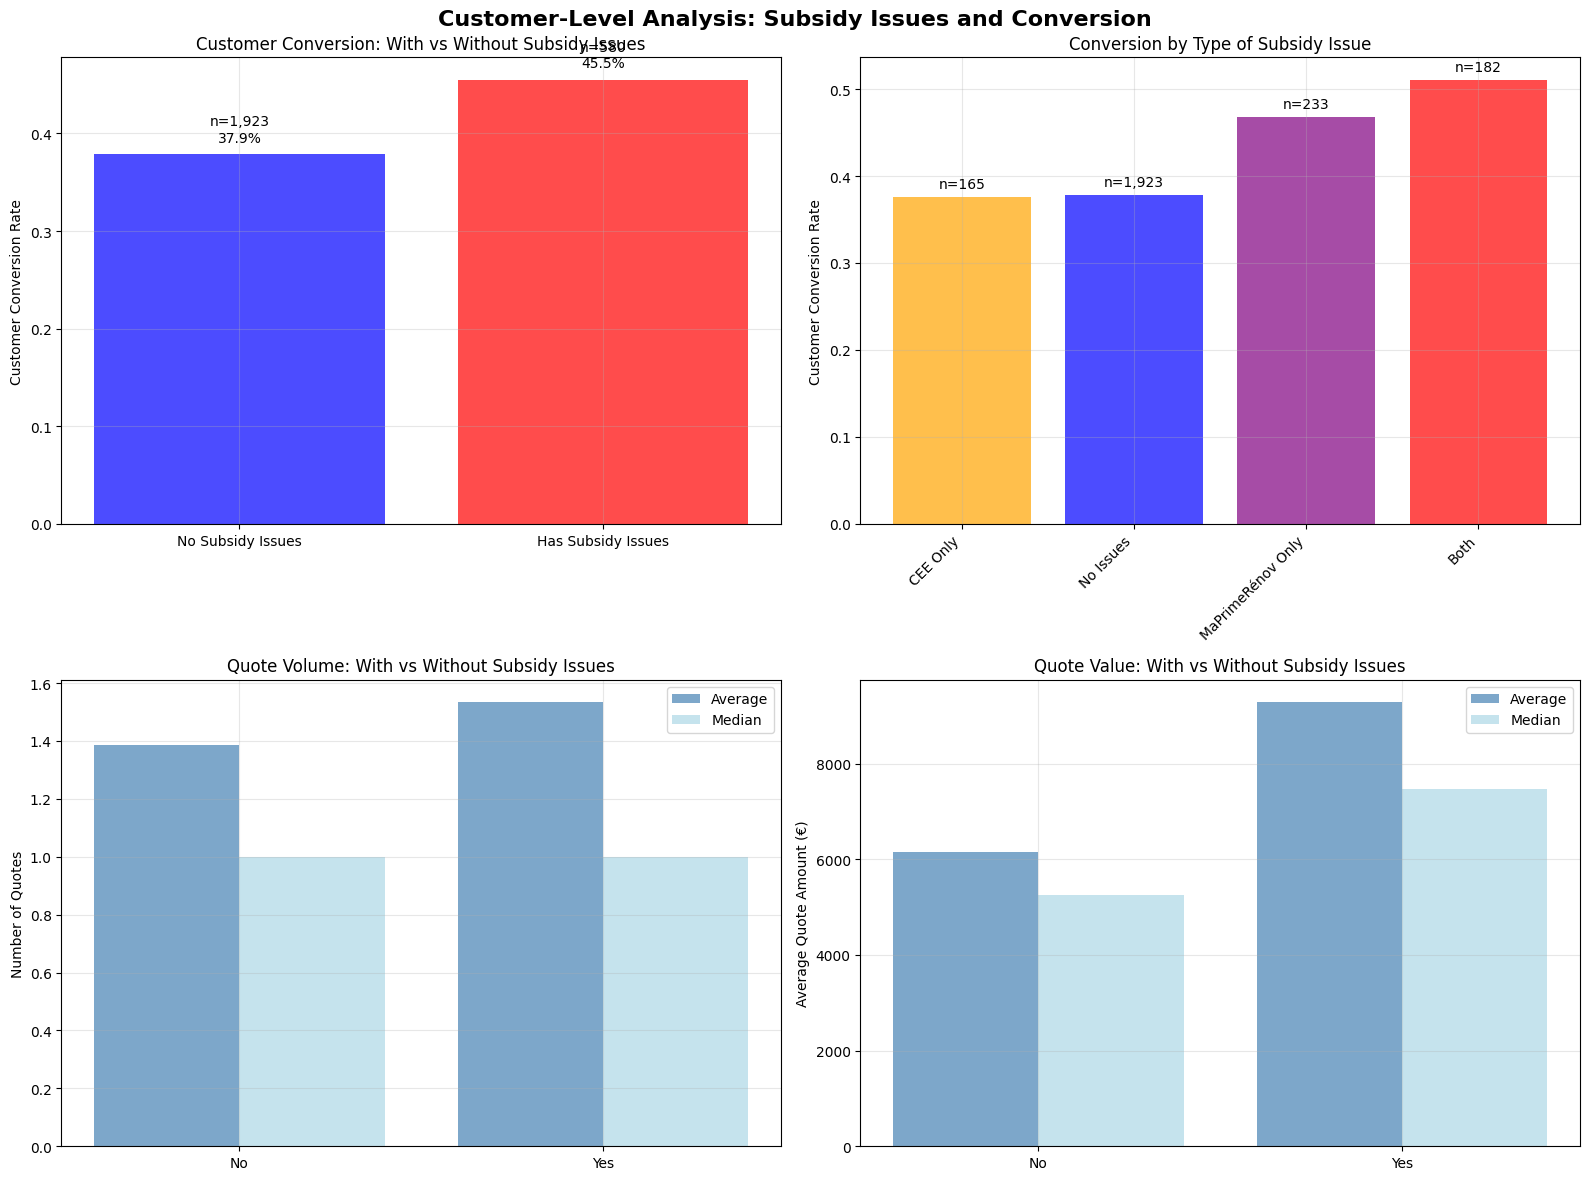


Policy Suspension Impact

Analyzing 2,414 customers
Price range: €1,312 to €26,385
Median price: €6,237
Unique values in during_suspension: [False]

⚠️  Only data during normal periods available

Conversion during subsidy suspensions:
                    mean  count
Normal Periods  0.397266   2414


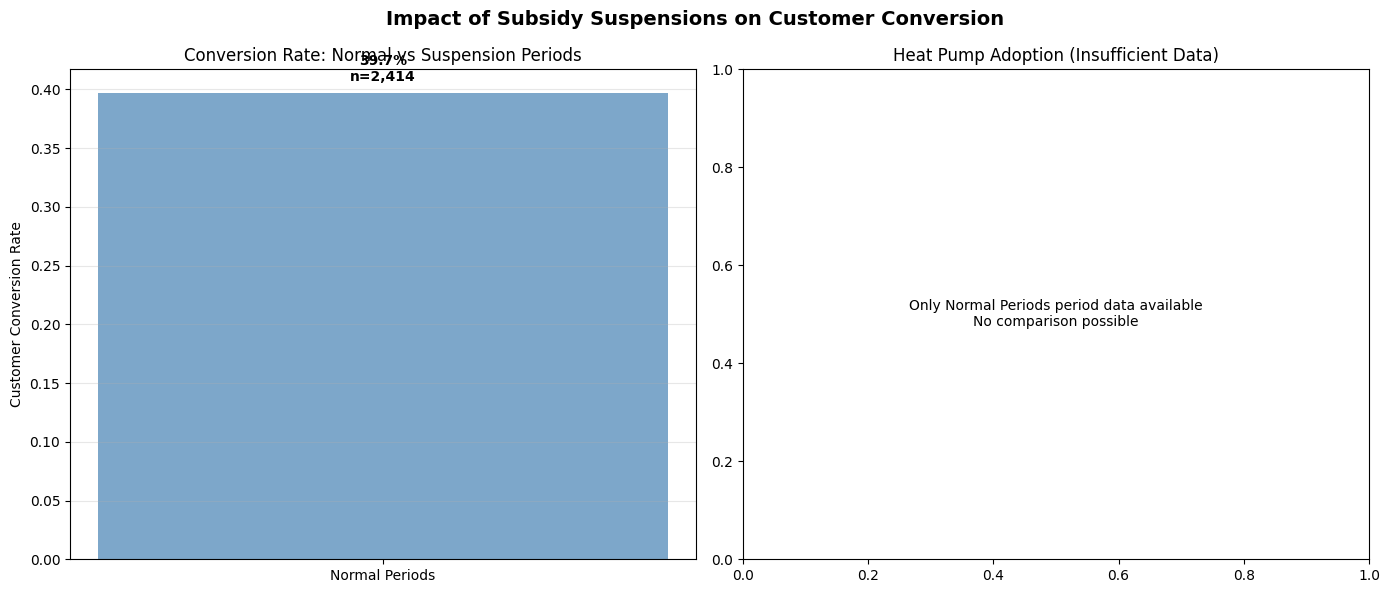

Unique values in main_product_family:
main_product_family
Chaudière                           858
Poêle                               612
Pompe à chaleur                     337
Climatisation                       325
ECS : Chauffe-eau ou adoucisseur    157
Photovoltaïque                       73
Emetteur de chauffage  ou chappe     39
Unknown                              33
Autres                               24
Appareil hybride                     19
Accessoire de pose                   14
Produit VMC                           9
Plomberie Sanitaire                   3
Name: count, dtype: int64

Top products:
main_product_family
Chaudière                           858
Poêle                               612
Pompe à chaleur                     337
Climatisation                       325
ECS : Chauffe-eau ou adoucisseur    157
Photovoltaïque                       73
Emetteur de chauffage  ou chappe     39
Unknown                              33
Autres                               24
A

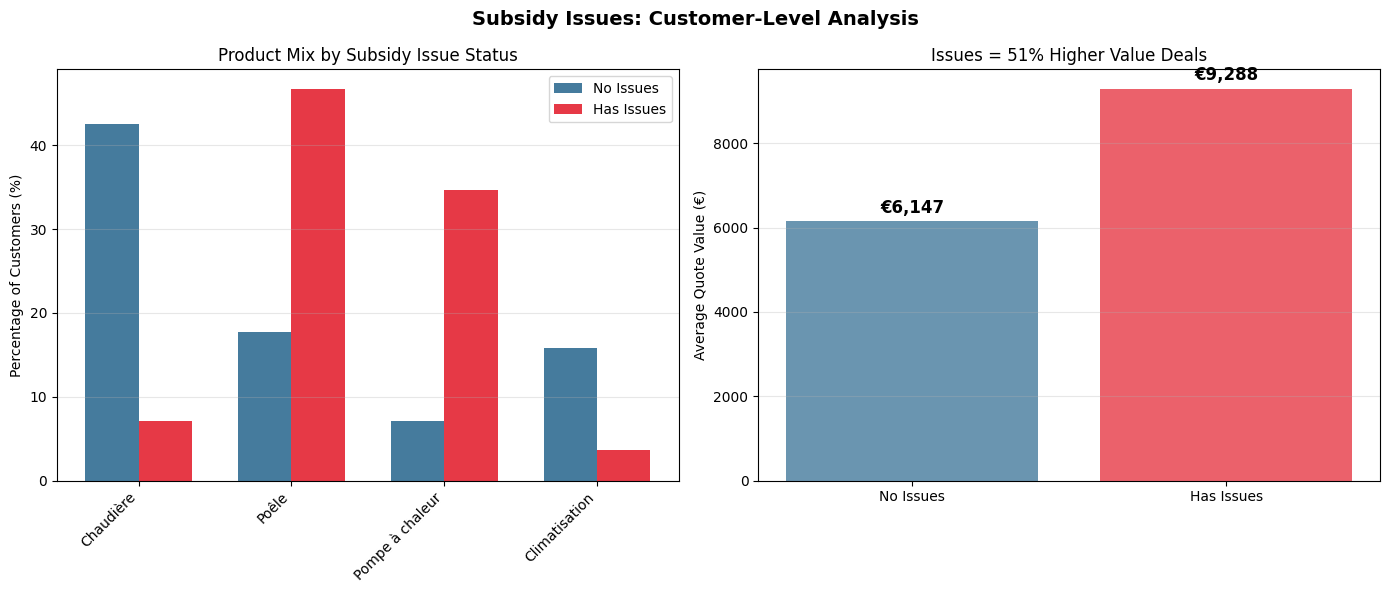


Threshold effect

Analyzing 2,414 customers
Price range: €1,312 to €26,385
Median price: €6,237


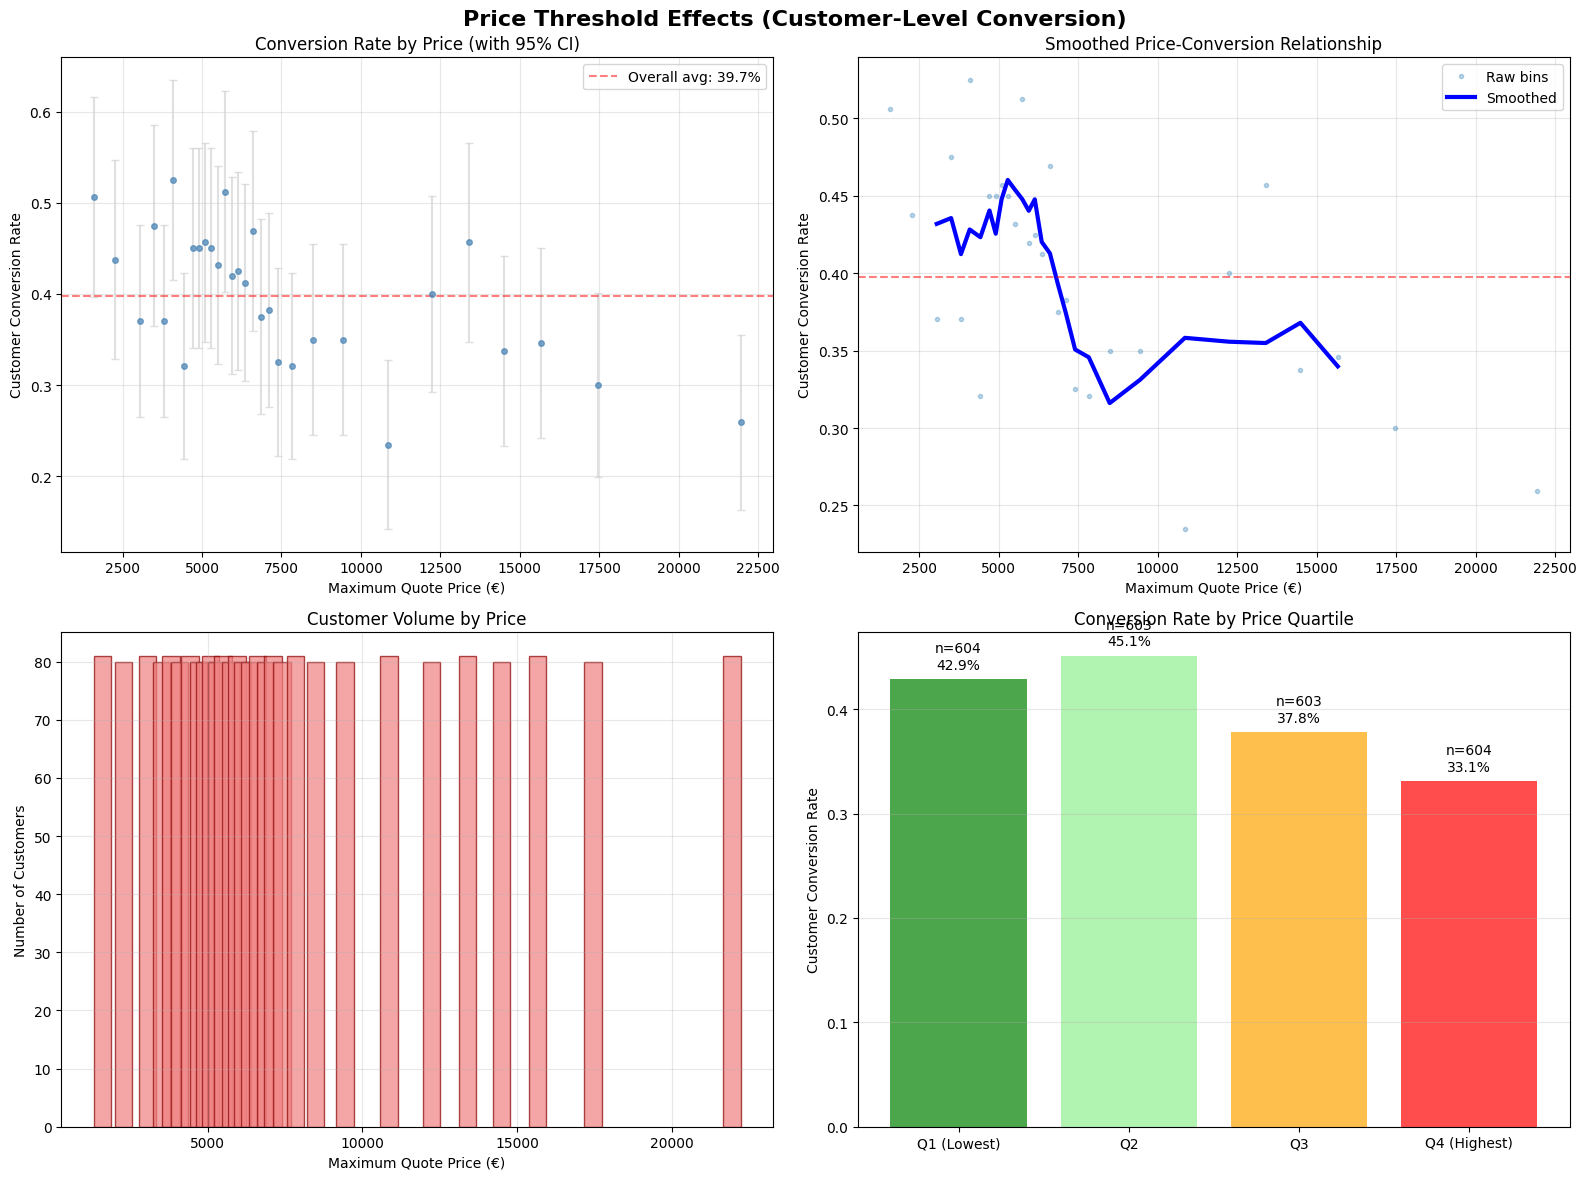


THRESHOLD EFFECT: KEY FINDINGS

Conversion by Price Quartile:
  Q1 (Lowest): 42.9% (n=604)
  Q2: 45.1% (n=603)
  Q3: 37.8% (n=603)
  Q4 (Highest): 33.1% (n=604)

Difference between lowest and highest quartile: 9.8 percentage points

Sweet spots (above-average conversion):
  €1,591: 50.6% (n=81)
  €2,277: 43.8% (n=80)
  €3,500: 47.5% (n=80)
  €4,084: 52.5% (n=80)
  €4,707: 45.0% (n=80)
  €4,903: 45.0% (n=80)
  €5,088: 45.7% (n=81)
  €5,282: 45.0% (n=80)
  €5,498: 43.2% (n=81)
  €5,738: 51.2% (n=80)
  €5,943: 42.0% (n=81)
  €6,132: 42.5% (n=80)
  €6,350: 41.2% (n=80)
  €6,608: 46.9% (n=81)
  €12,243: 40.0% (n=80)
  €13,398: 45.7% (n=81)

Analyzing 2,414 customers
Price range: €1,312 to €26,385
Median price: €6,237

Product mix by price quartile

Product distribution by price quartile (%):
main_equipment_category    AC  Boiler  Heat Pump  Other  Stove
price_quartile                                                
Q1_Low                   11.5    43.2        0.8   34.7    9.7
Q2_MidLow   

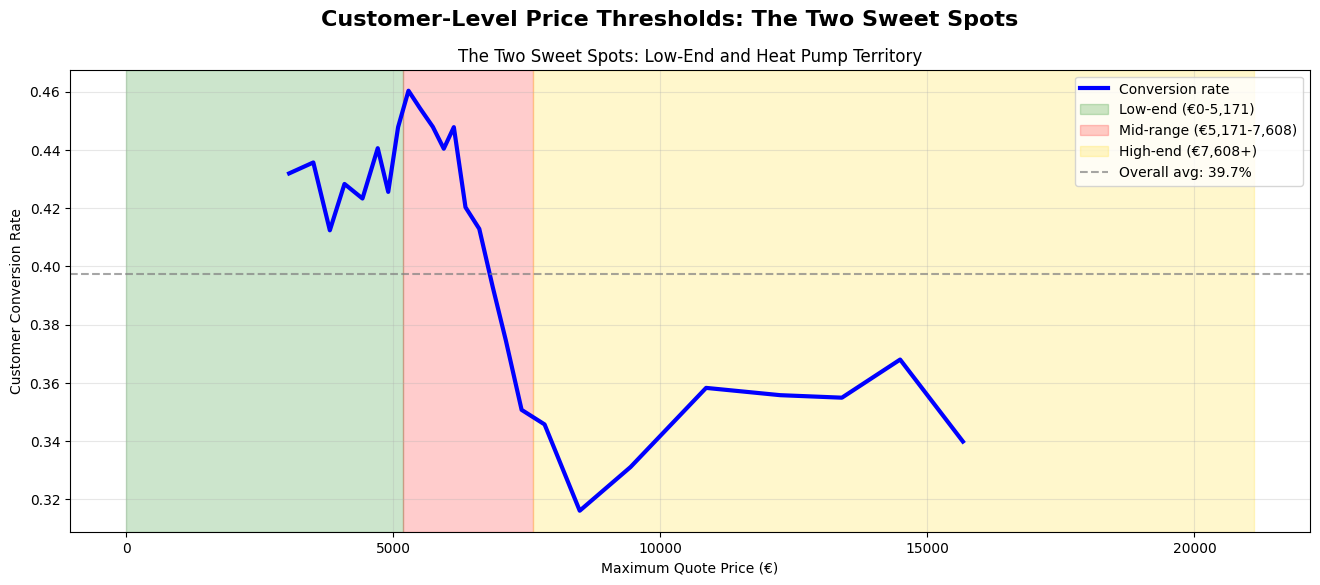

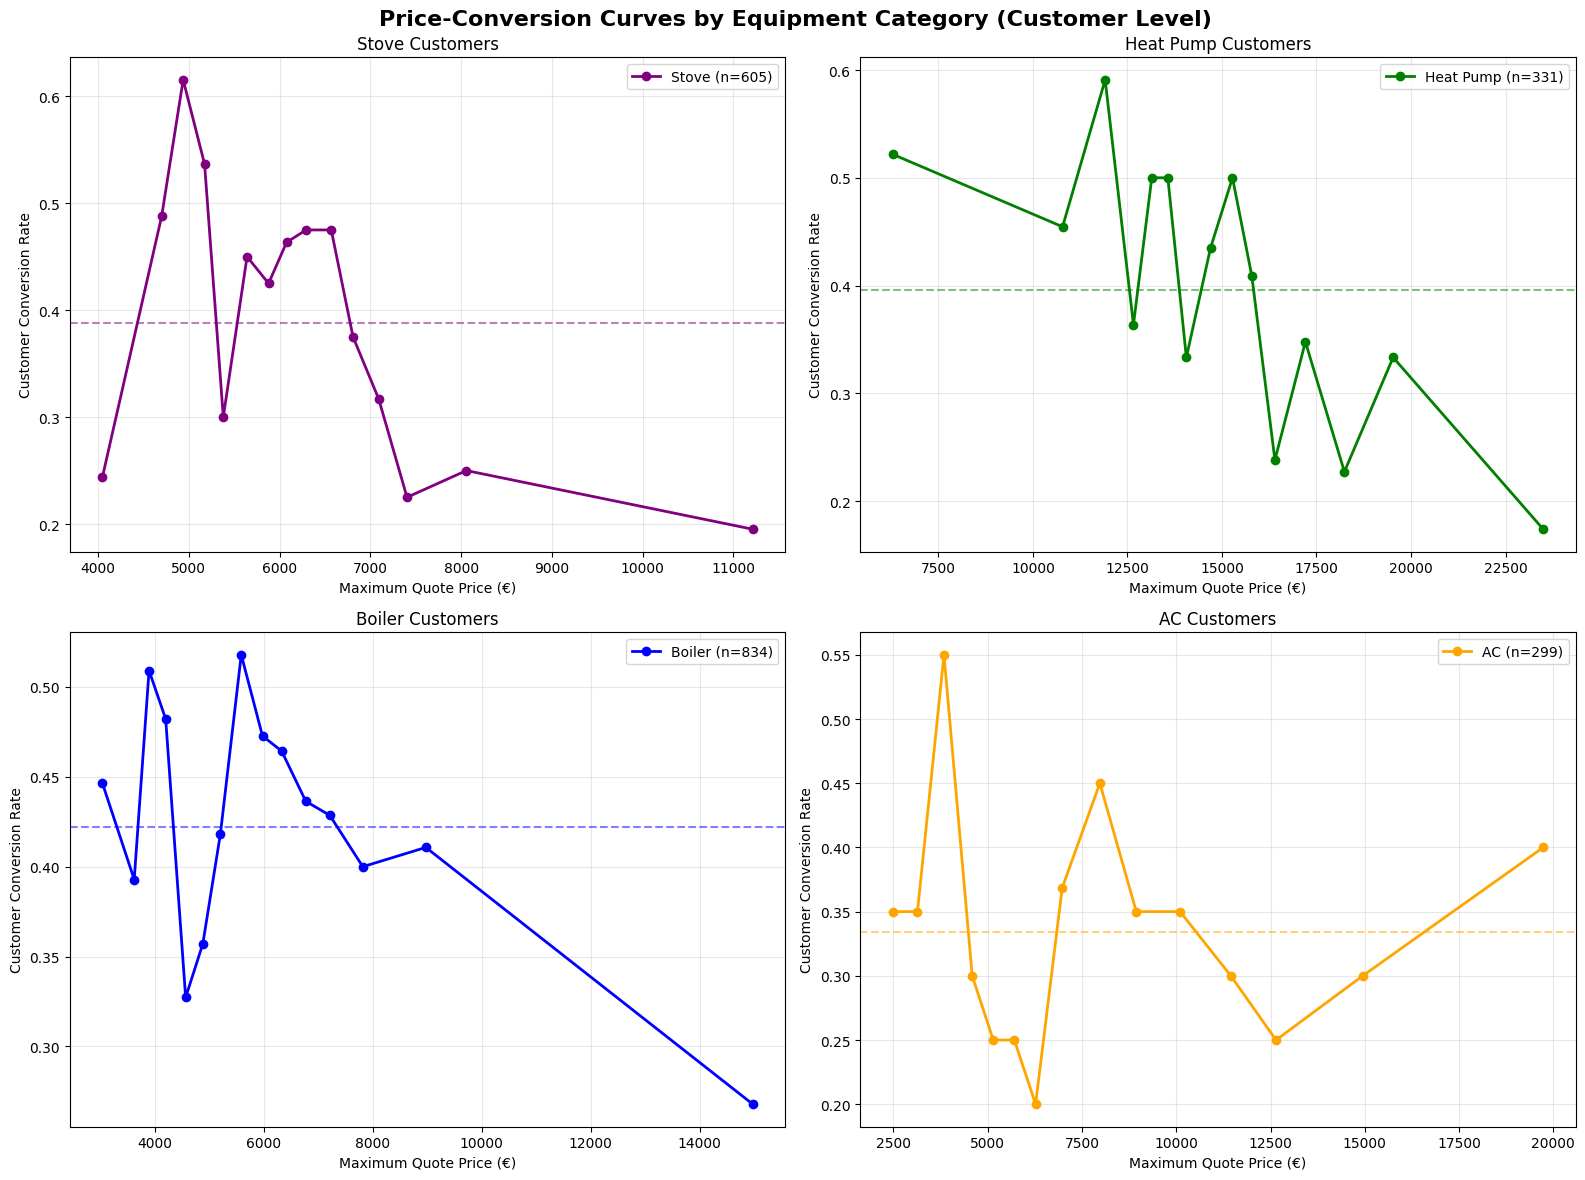


Conversion by Brand Price

Analyzing 2,414 customers
Price range: €1,312 to €26,385
Median price: €6,237
Top 8 brands: ['ATLANTIC', 'MITSUBISHI ELECTRIC', 'MCZ', 'FRISQUET', 'E.L.M. LEBLANC', 'DE DIETRICH', 'SAUNIER DUVAL', 'SOL&MOI']


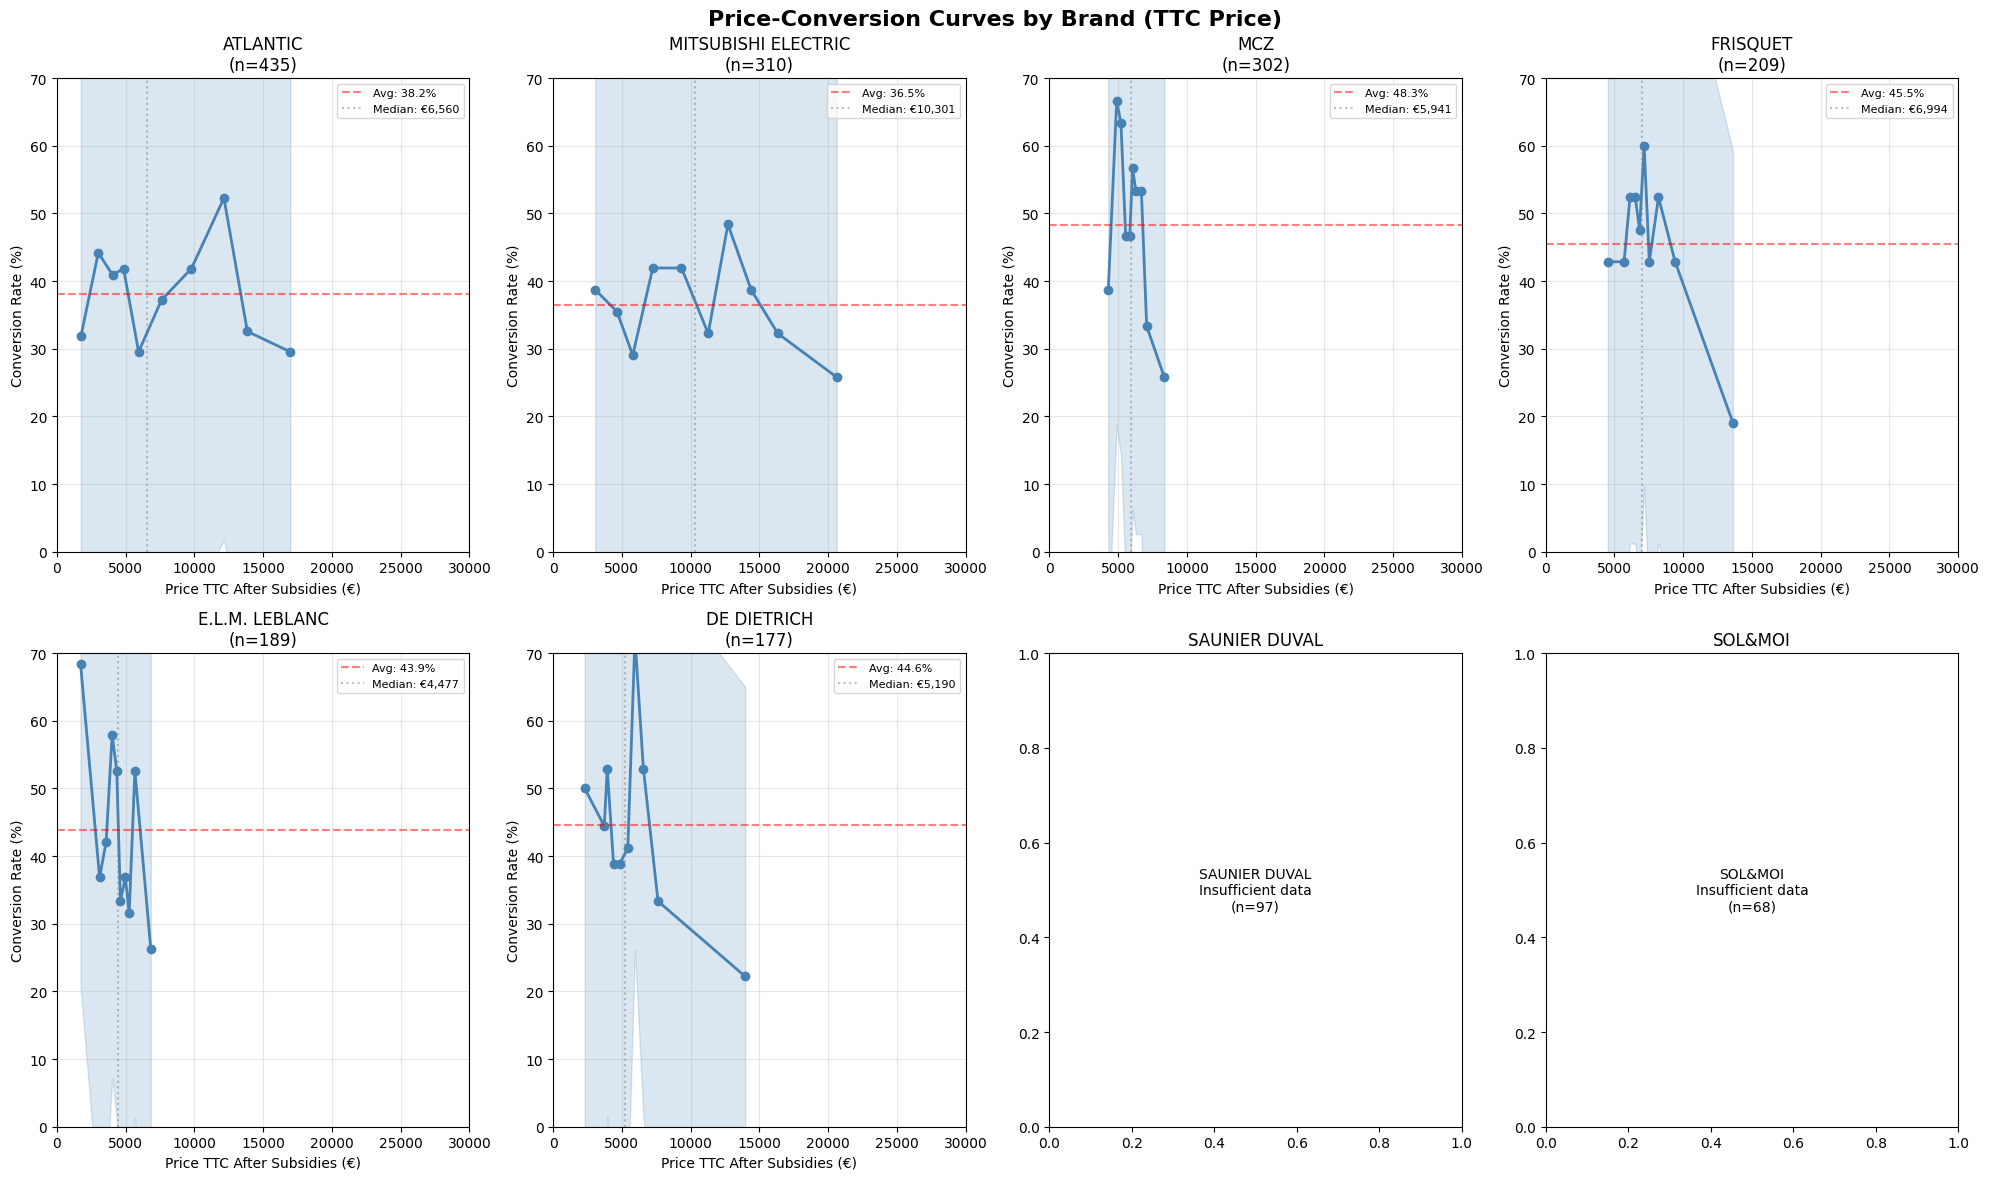


Analyzing 2,414 customers
Price range: €1,312 to €26,385
Median price: €6,237


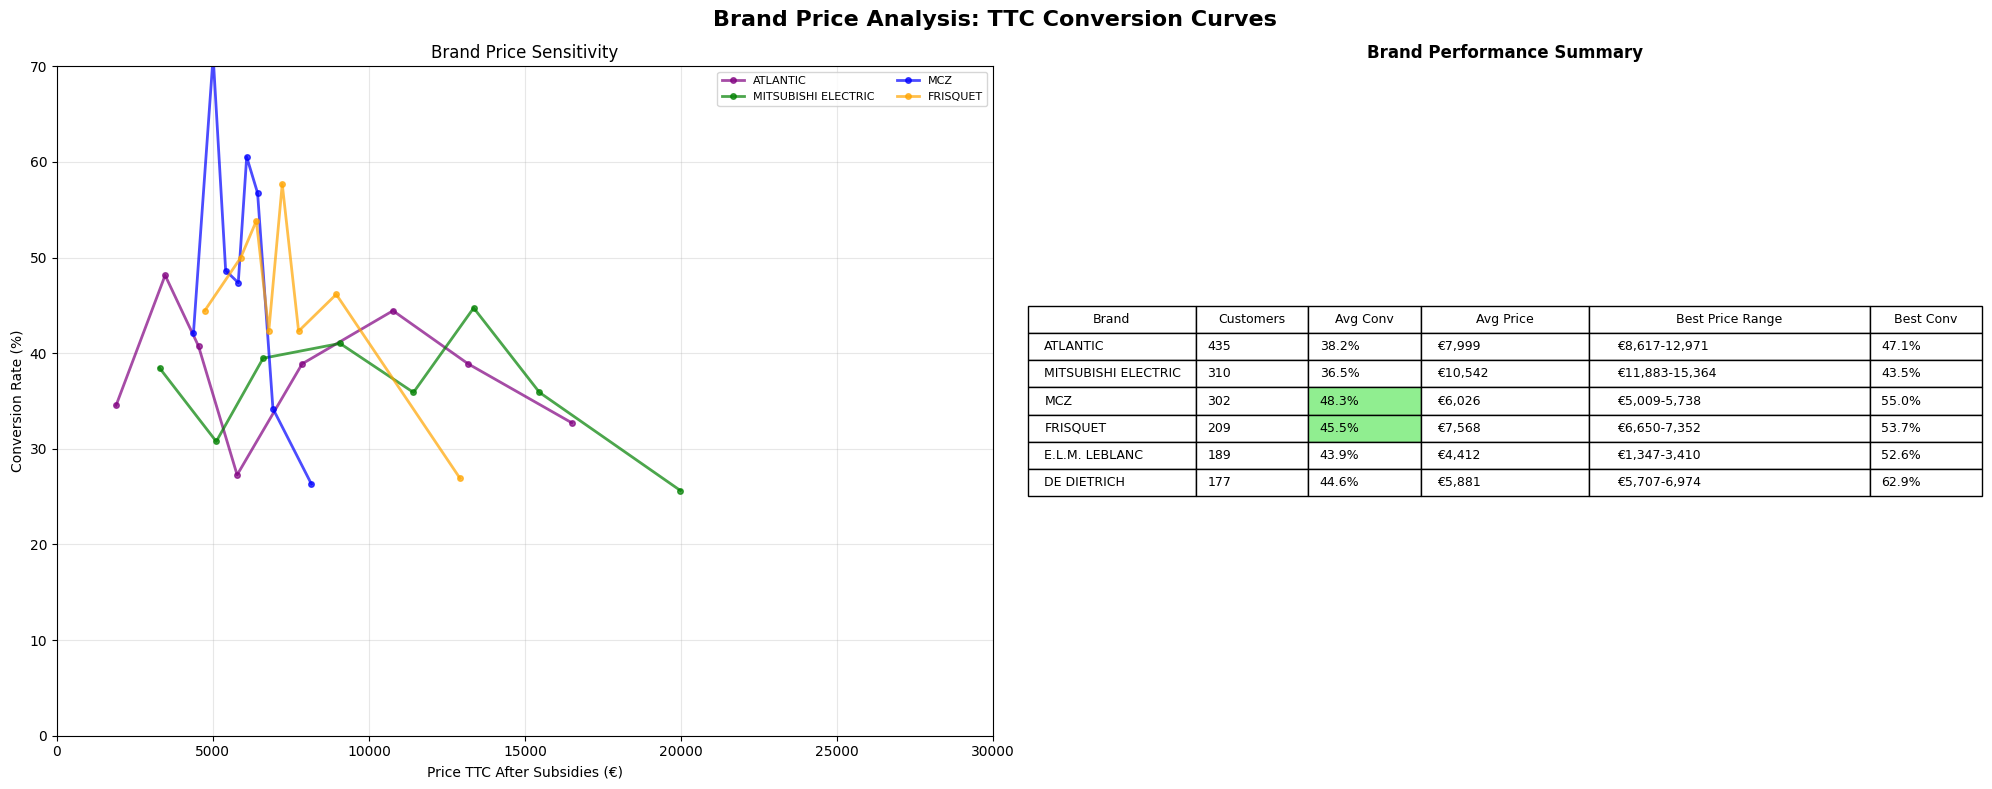


TTC Price-conversion curves: 4 equipment types, multiple brands per graph

Analyzing 2,414 customers
Price range: €1,312 to €26,385
Median price: €6,237

Heat Pump - Top brands: ['ATLANTIC', 'MITSUBISHI ELECTRIC']

Boiler - Top brands: ['FRISQUET', 'E.L.M. LEBLANC', 'DE DIETRICH', 'ATLANTIC', 'SAUNIER DUVAL']

Stove - Top brands: ['MCZ', 'JOLLY MEC', 'ORANIER']

AC - Top brands: ['MITSUBISHI ELECTRIC', 'ATLANTIC']


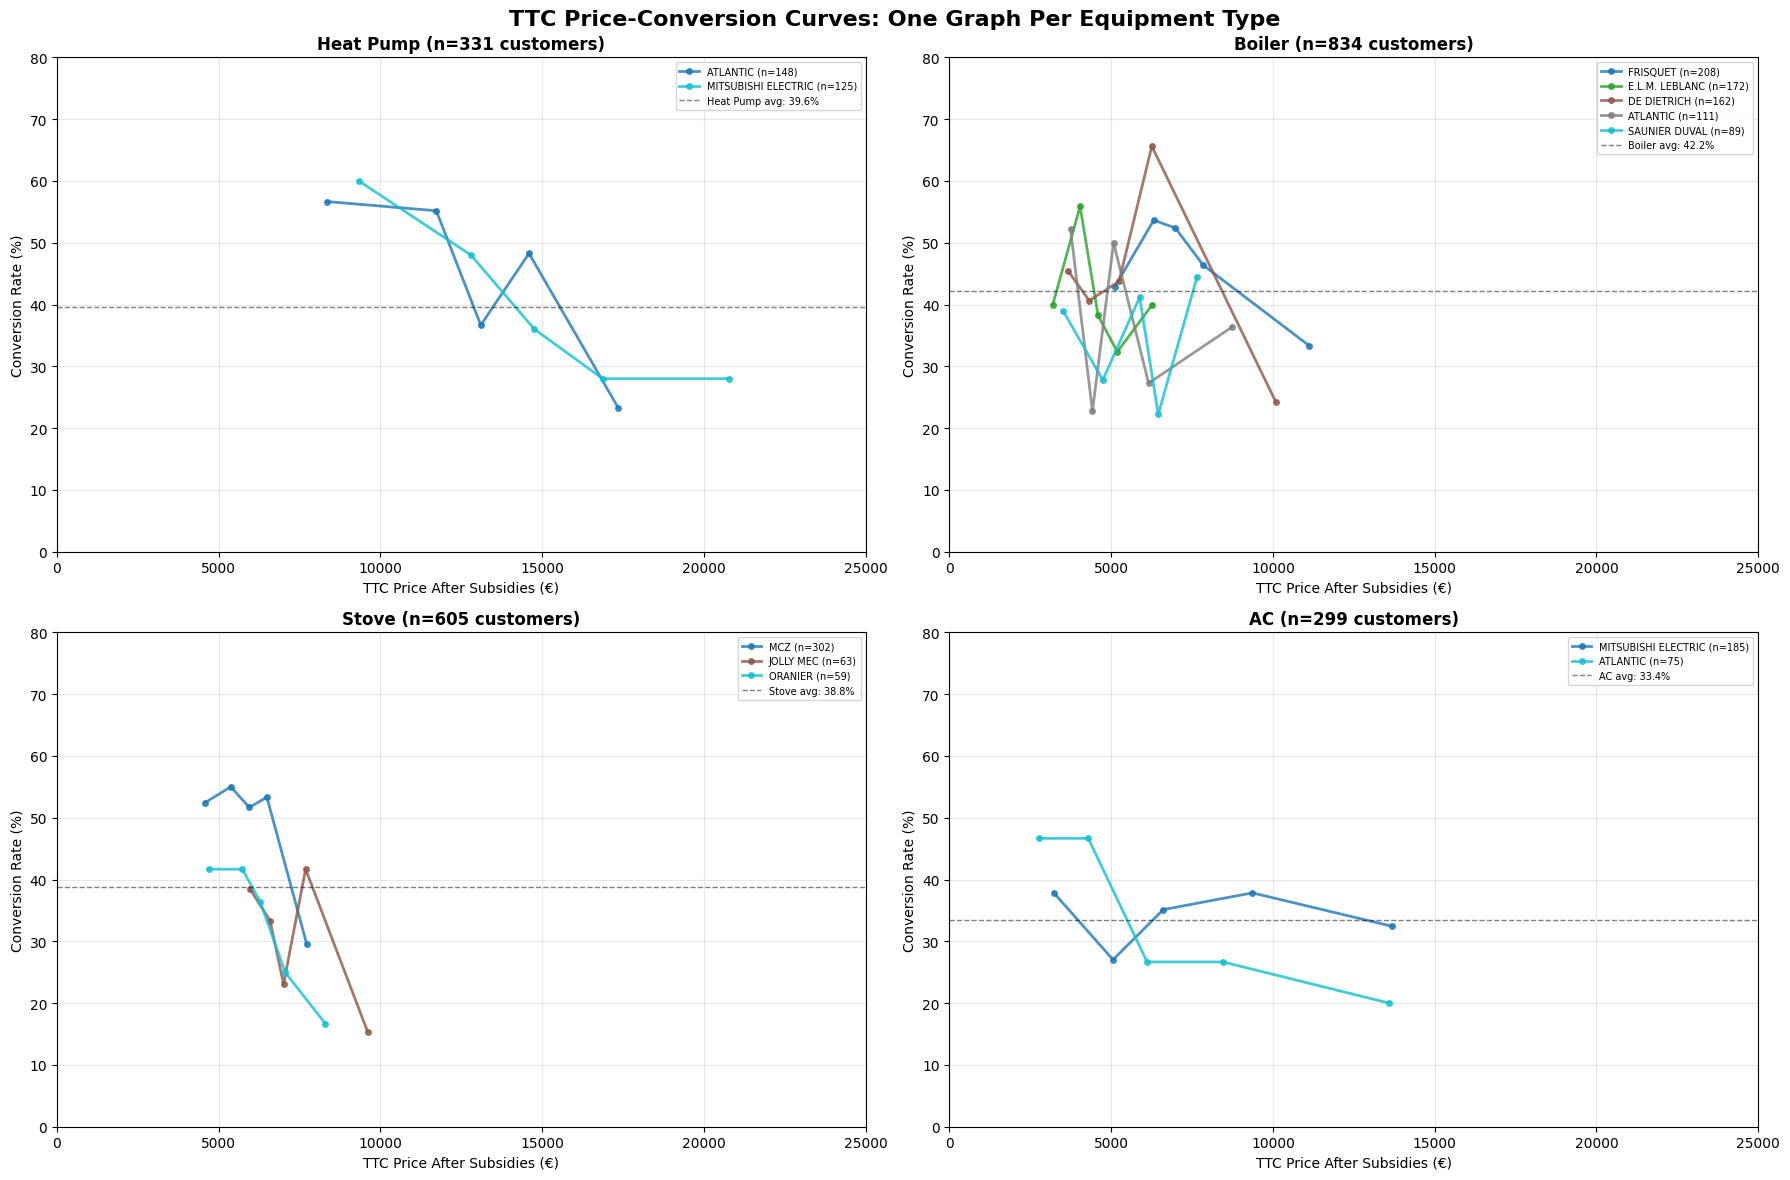


Seasonal Effects on Customer Conversion


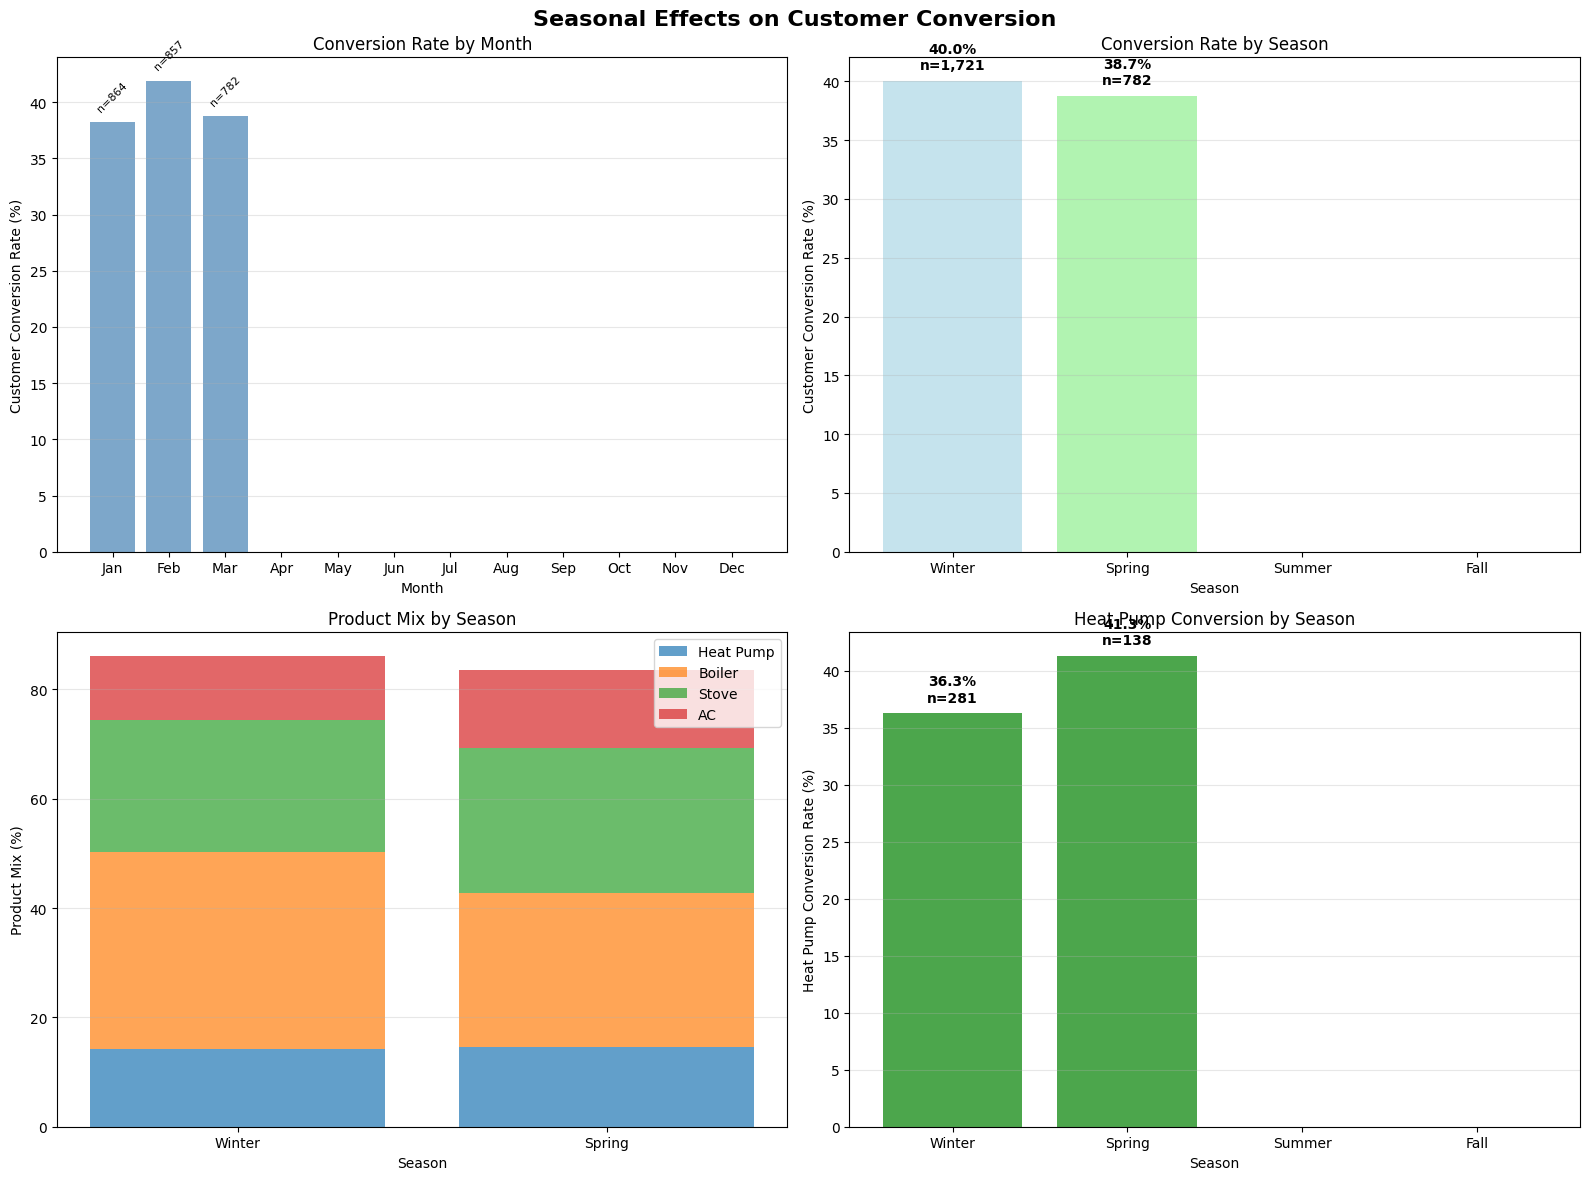


SEASONAL STATISTICS

Conversion by season:
  Winter: 40.0% (n=1,721)
  Spring: 38.7% (n=782)

Seasonality chi-square p-value: 0.5710
Statistically significant: NO

Regional Seasonal Pattern

Analyzing 2,414 customers
Price range: €1,312 to €26,385
Median price: €6,237

Top regions: ['Normandie', 'Hauts-de-France', 'Auvergne-Rhône-Alpes']


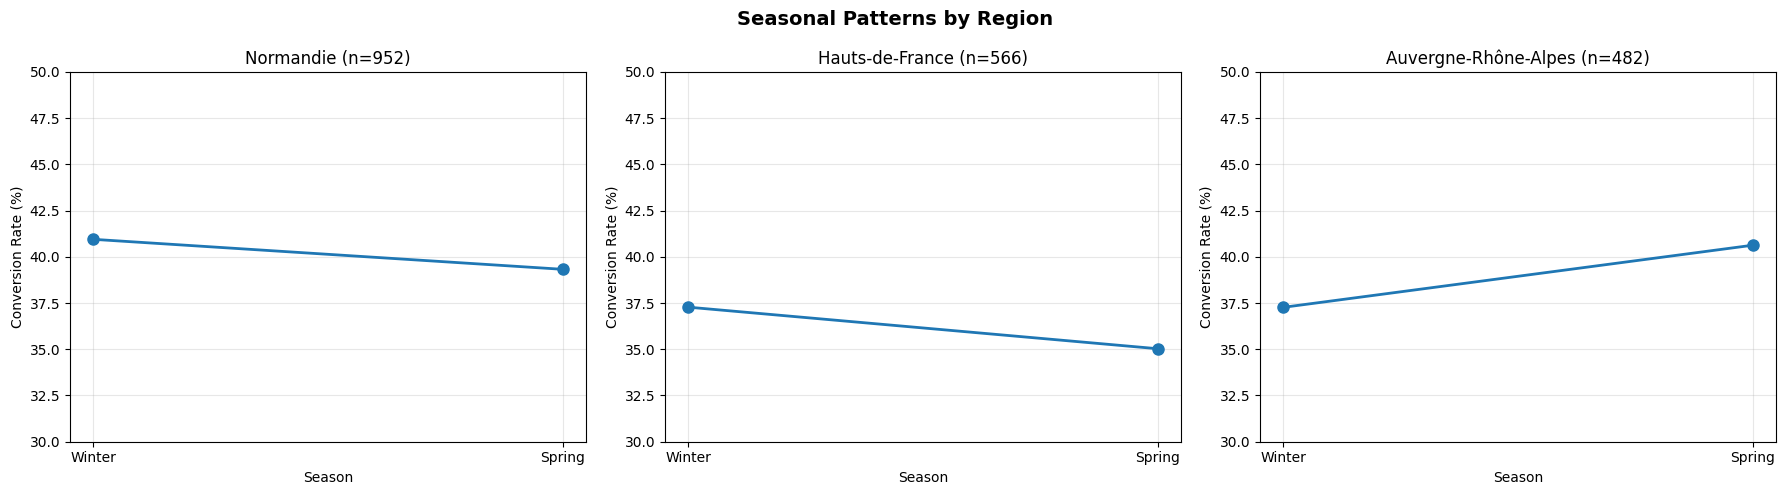


Year-over-year trends

Analyzing 2,414 customers
Price range: €1,312 to €26,385
Median price: €6,237

Quarterly conversion rates:
                  mean  count
year_quarter                 
2025Q1        0.397266   2414


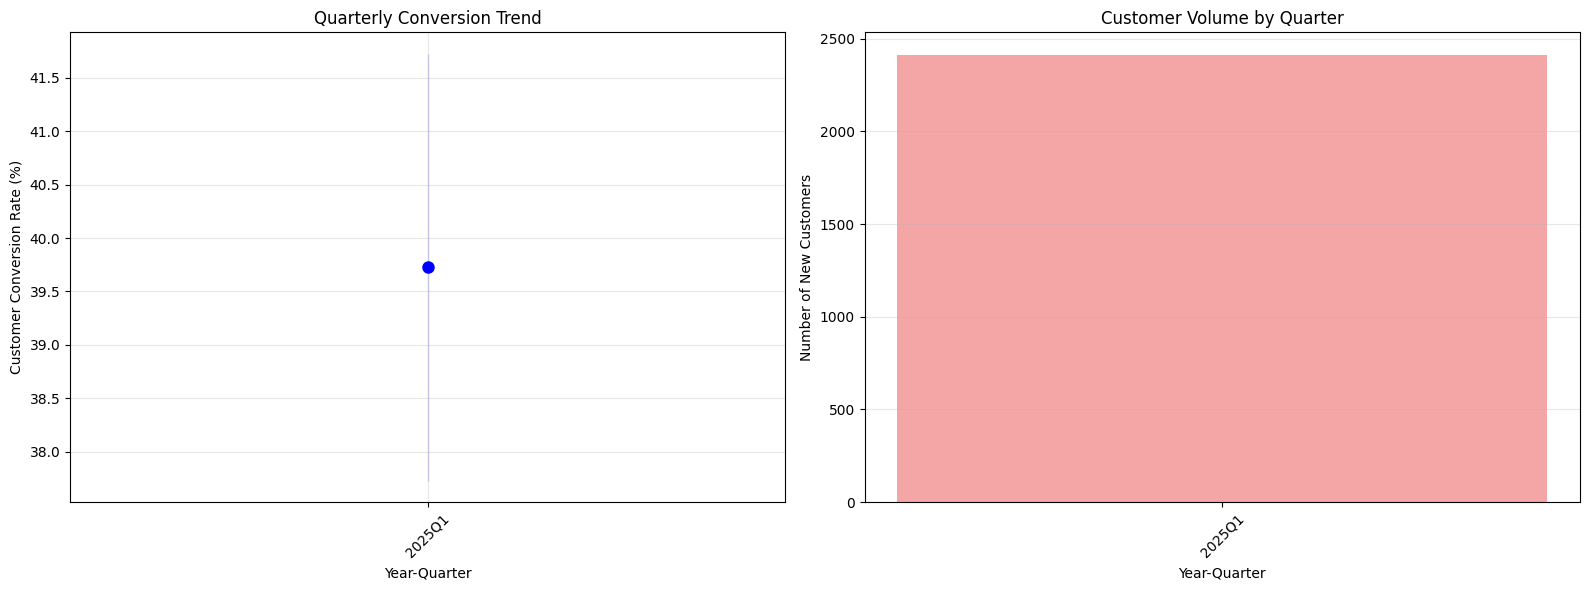


Best and Worst Months Report

Analyzing 2,414 customers
Price range: €1,312 to €26,385
Median price: €6,237

⚠️  Only one suspension period found: [False]
Skipping suspension comparison

Best month: 2 (42.3%, n=823)

Best season: Winter (40.2%)
Worst season: Spring (38.6%)

Heat pump conversion by season:
  Winter: 36.9%
  Spring: 43.2%

Analyzing 2,414 customers
Price range: €1,312 to €26,385
Median price: €6,237


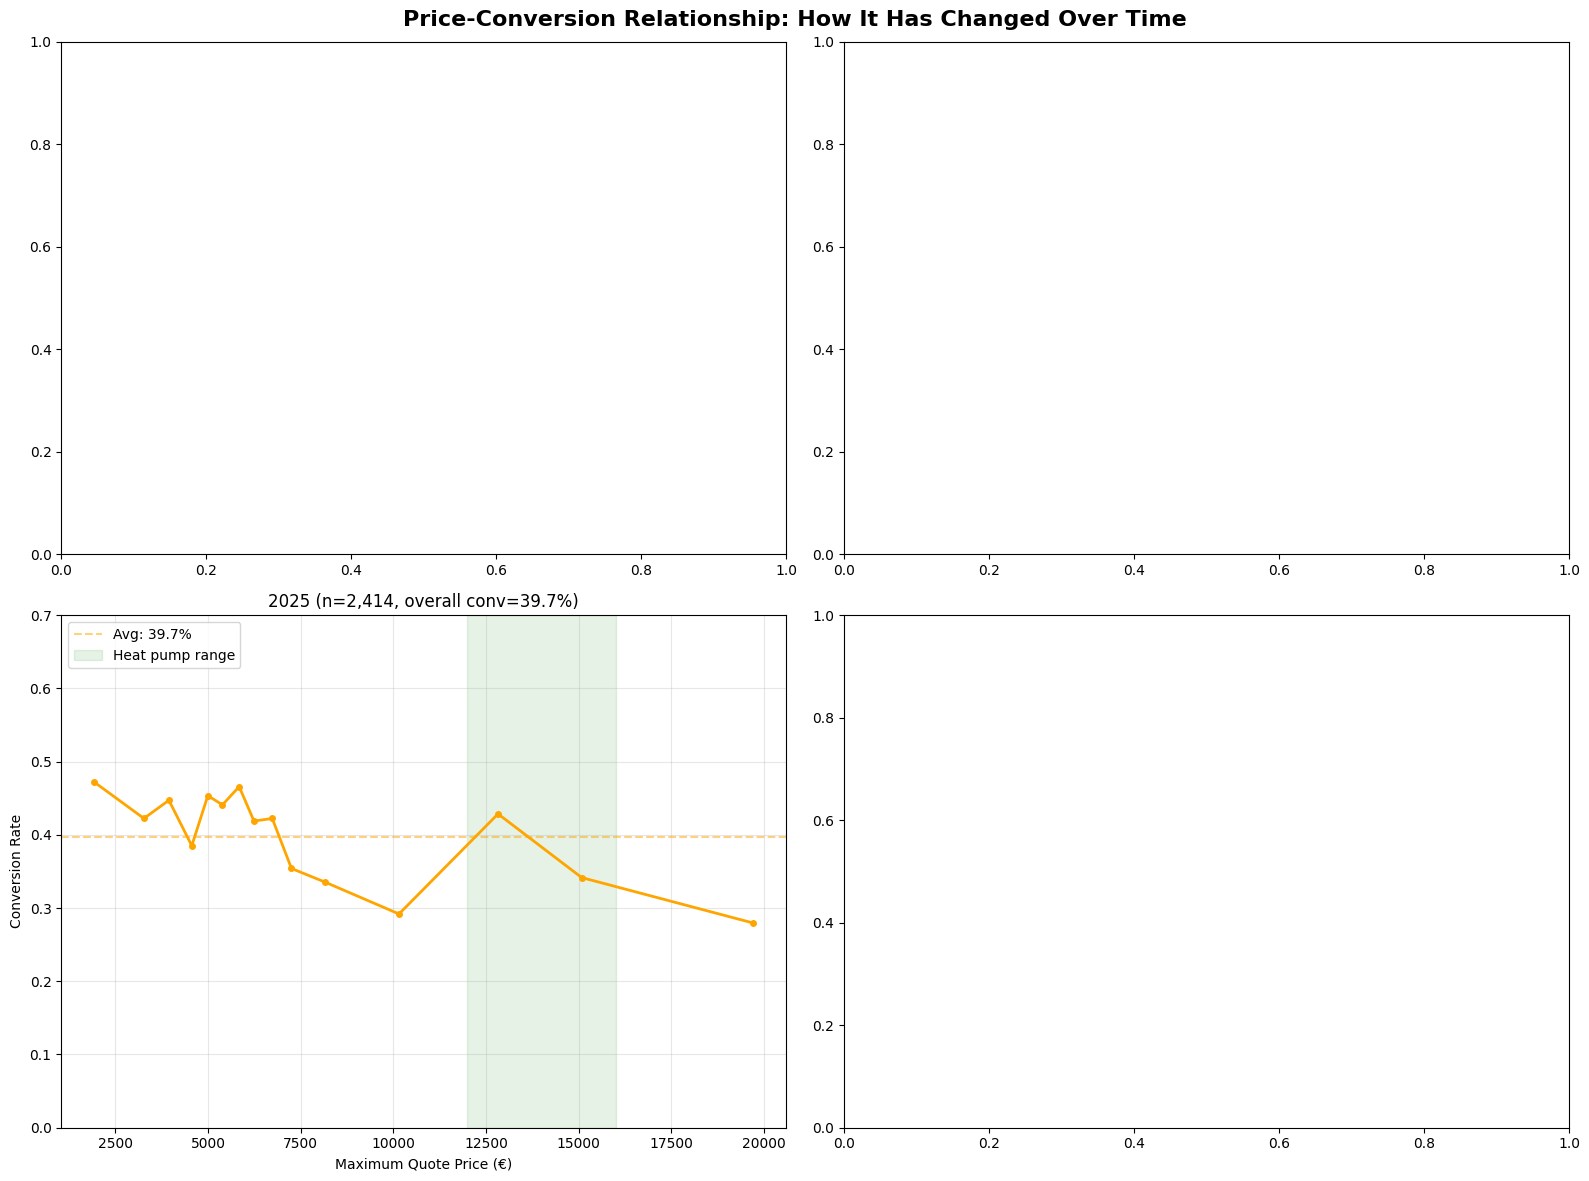


Analyzing 2,414 customers
Price range: €1,312 to €26,385
Median price: €6,237


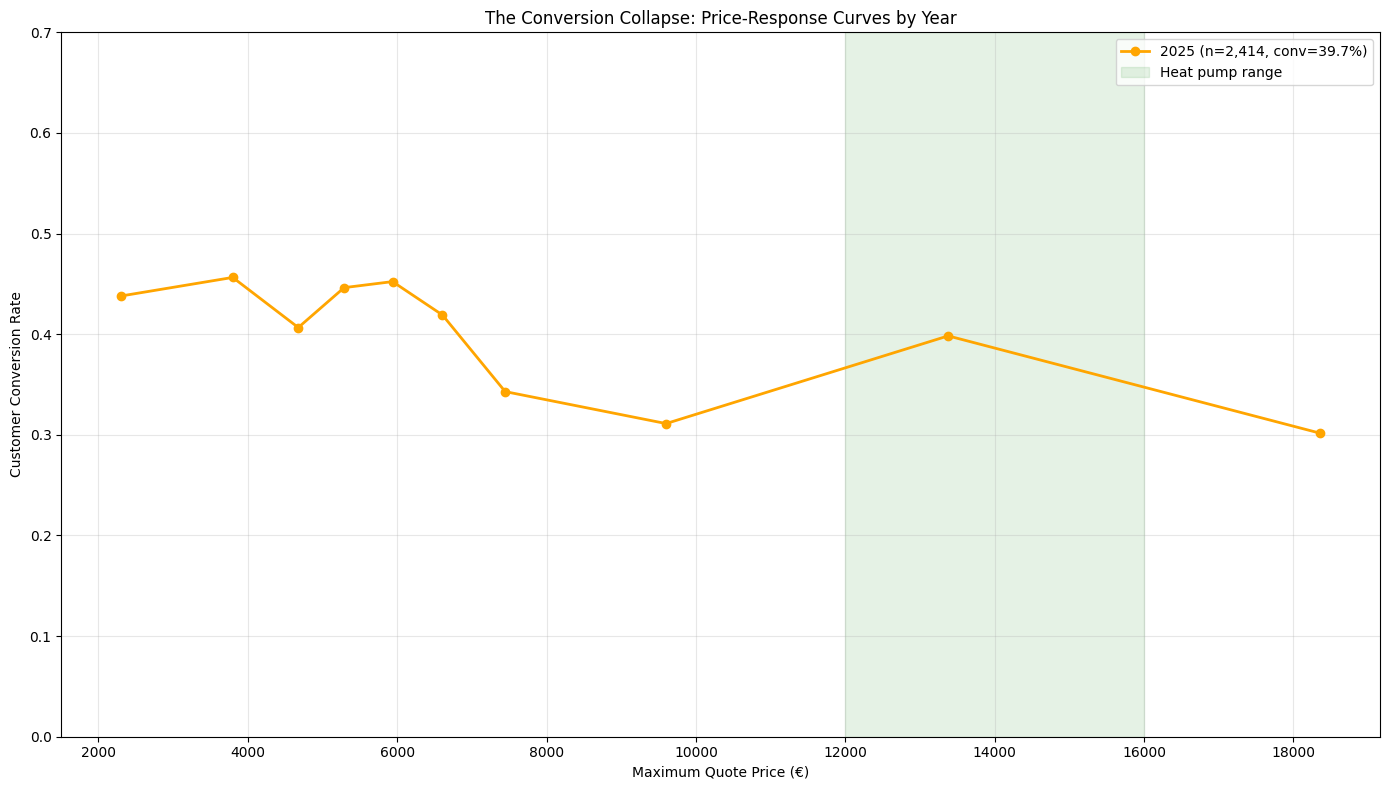


Sweet Spot Analysis Over Time

Analyzing 2,414 customers
Price range: €1,312 to €26,385
Median price: €6,237

Sweet spots by year (price points with conversion > avg + 3%):

2025 (overall avg: 39.7%):
  €1,733: 47.9% (n=121)
  €4,011: 50.4% (n=121)
  €4,857: 45.8% (n=120)
  €5,136: 48.8% (n=121)
  €5,792: 43.3% (n=120)
  €6,082: 47.1% (n=121)
  €6,417: 45.5% (n=121)


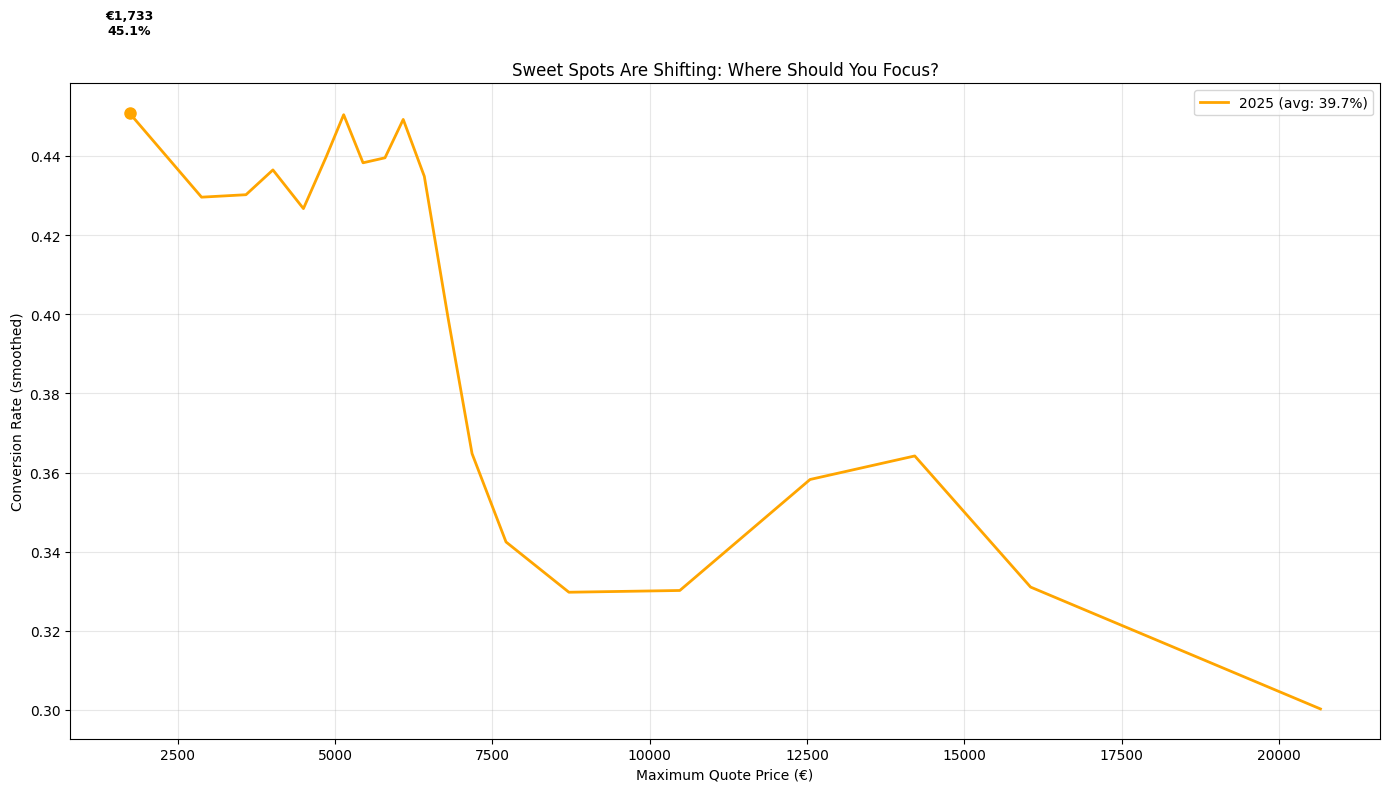


Administrative Uncertainty Effect

Analyzing 2,414 customers
Price range: €1,312 to €26,385
Median price: €6,237

Decision time distribution:
count    2414.000000
mean       15.908865
std        57.837648
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max       429.000000
Name: decision_days, dtype: float64

Customers with 1-day decision: 1,995 (82.6%)


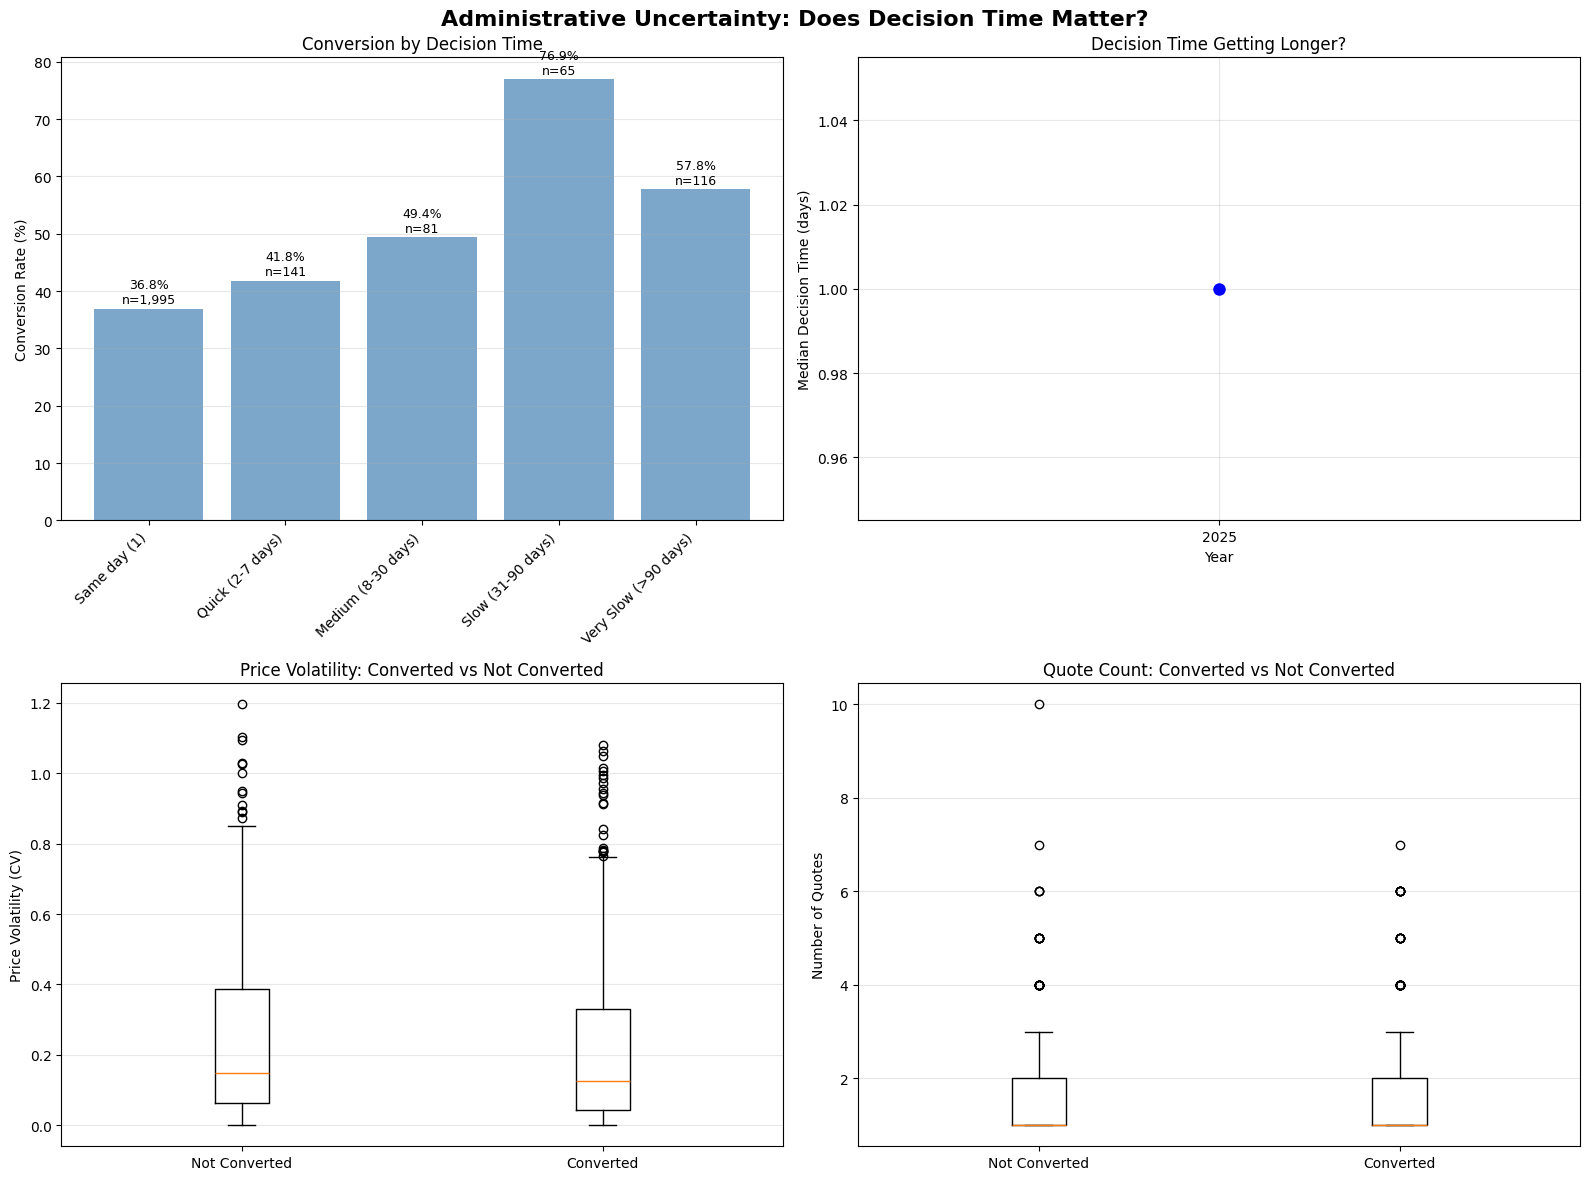


Product Type - Price Conversion Heatmap
Simple pivot table:
price_bin_simple         (1133.359, 4160.648]  (4160.648, 5615.674]  \
main_equipment_category                                               
AC                                  40.983607             27.083333   
Boiler                              44.845361             39.737991   
Heat Pump                           40.000000             80.000000   
Other                               48.325359             70.000000   
Stove                               25.000000             47.120419   

price_bin_simple         (5615.674, 6995.726]  (6995.726, 11889.604]  \
main_equipment_category                                                
AC                                  19.512195              37.931034   
Boiler                              47.368421              38.797814   
Heat Pump                           25.000000              52.380952   
Other                               63.157895              12.500000   
Stove    

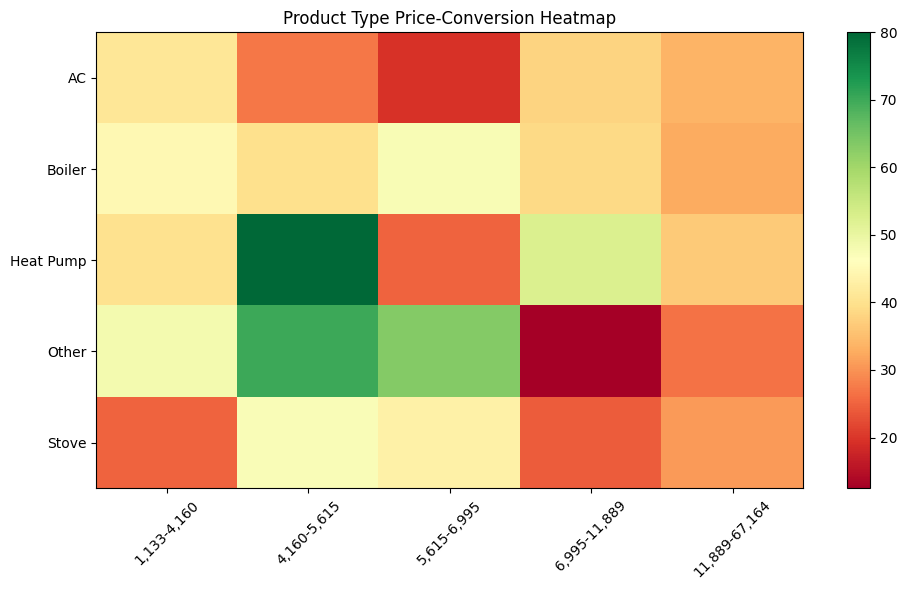


CHECKING MAIN PRODUCT FAMILY
main_product_family
Chaudière                           858
Poêle                               612
Pompe à chaleur                     337
Climatisation                       325
ECS : Chauffe-eau ou adoucisseur    157
Photovoltaïque                       73
Emetteur de chauffage  ou chappe     39
Unknown                              33
Autres                               24
Appareil hybride                     19
Accessoire de pose                   14
Produit VMC                           9
Plomberie Sanitaire                   3
Name: count, dtype: int64

Analyzing 2,414 customers
Price range: €1,312 to €26,385
Median price: €6,237


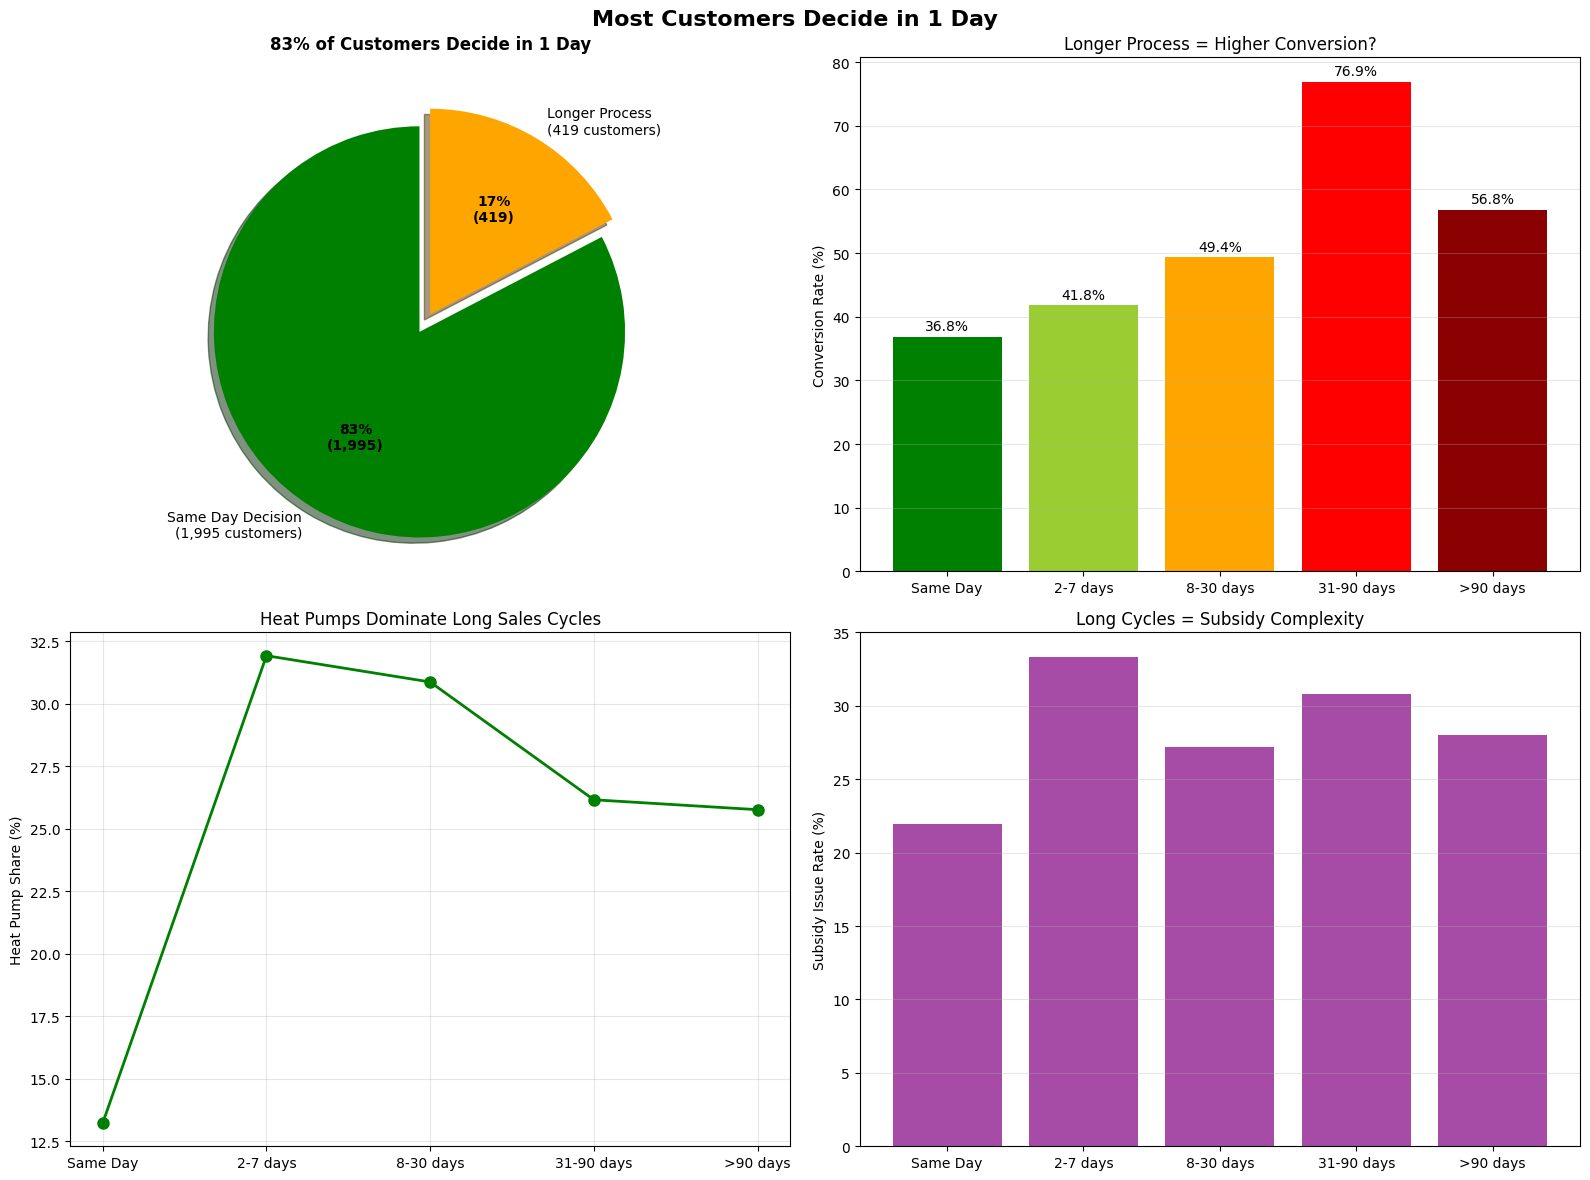


Heat Pump Performance Over Time

Analyzing 2,414 customers
Price range: €1,312 to €26,385
Median price: €6,237

Heat pump customers by year:
        conversion_rate  customer_count  avg_price  subsidy_issue_rate
period                                                                
2025               0.39             385  14893.519               0.636


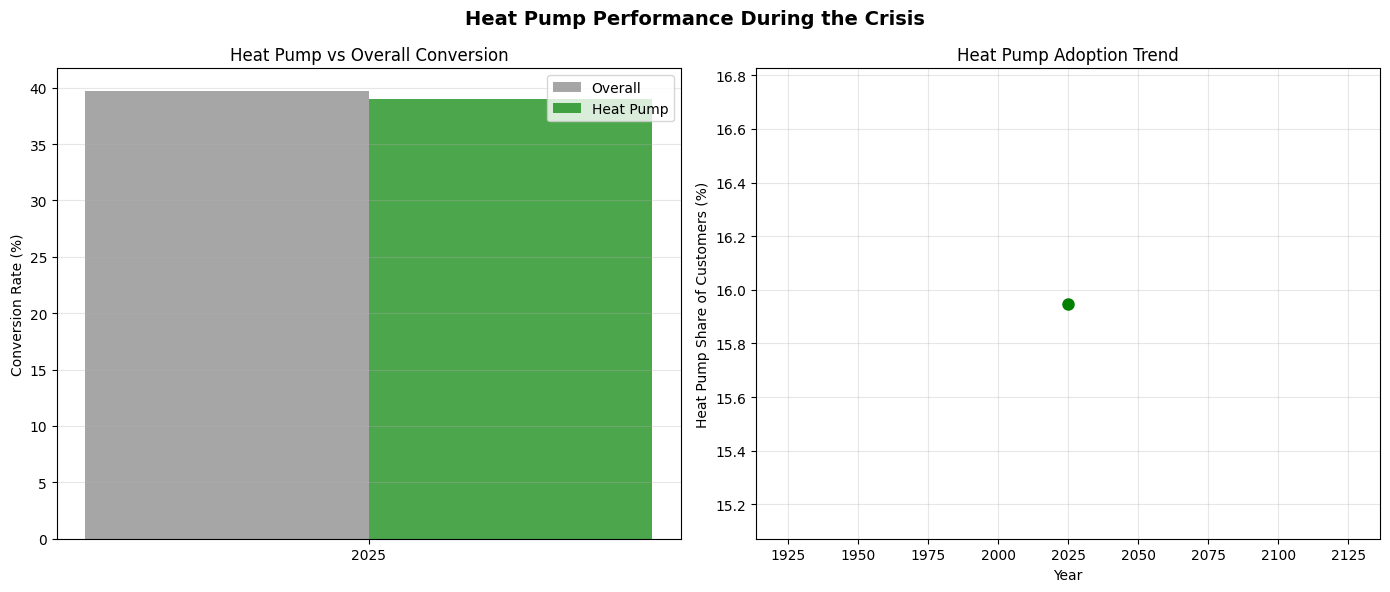


Analyzing 2,414 customers
Price range: €1,312 to €26,385
Median price: €6,237

DYNAMIC INSIGHTS CALCULATED:
Sweet spots: €4.1k (52.5%) and €5.7k (51.2%)
Dead zone: €10.0k-11.7k (23-35%)
Heat pumps: 64% subsidy issues, 39.0% conversion
Price sensitivity: Heat Pump (24.1pts) > Stove (22.4pts) > AC (9.3pts) > Boiler (8.6pts)
Same day decisions: 83%


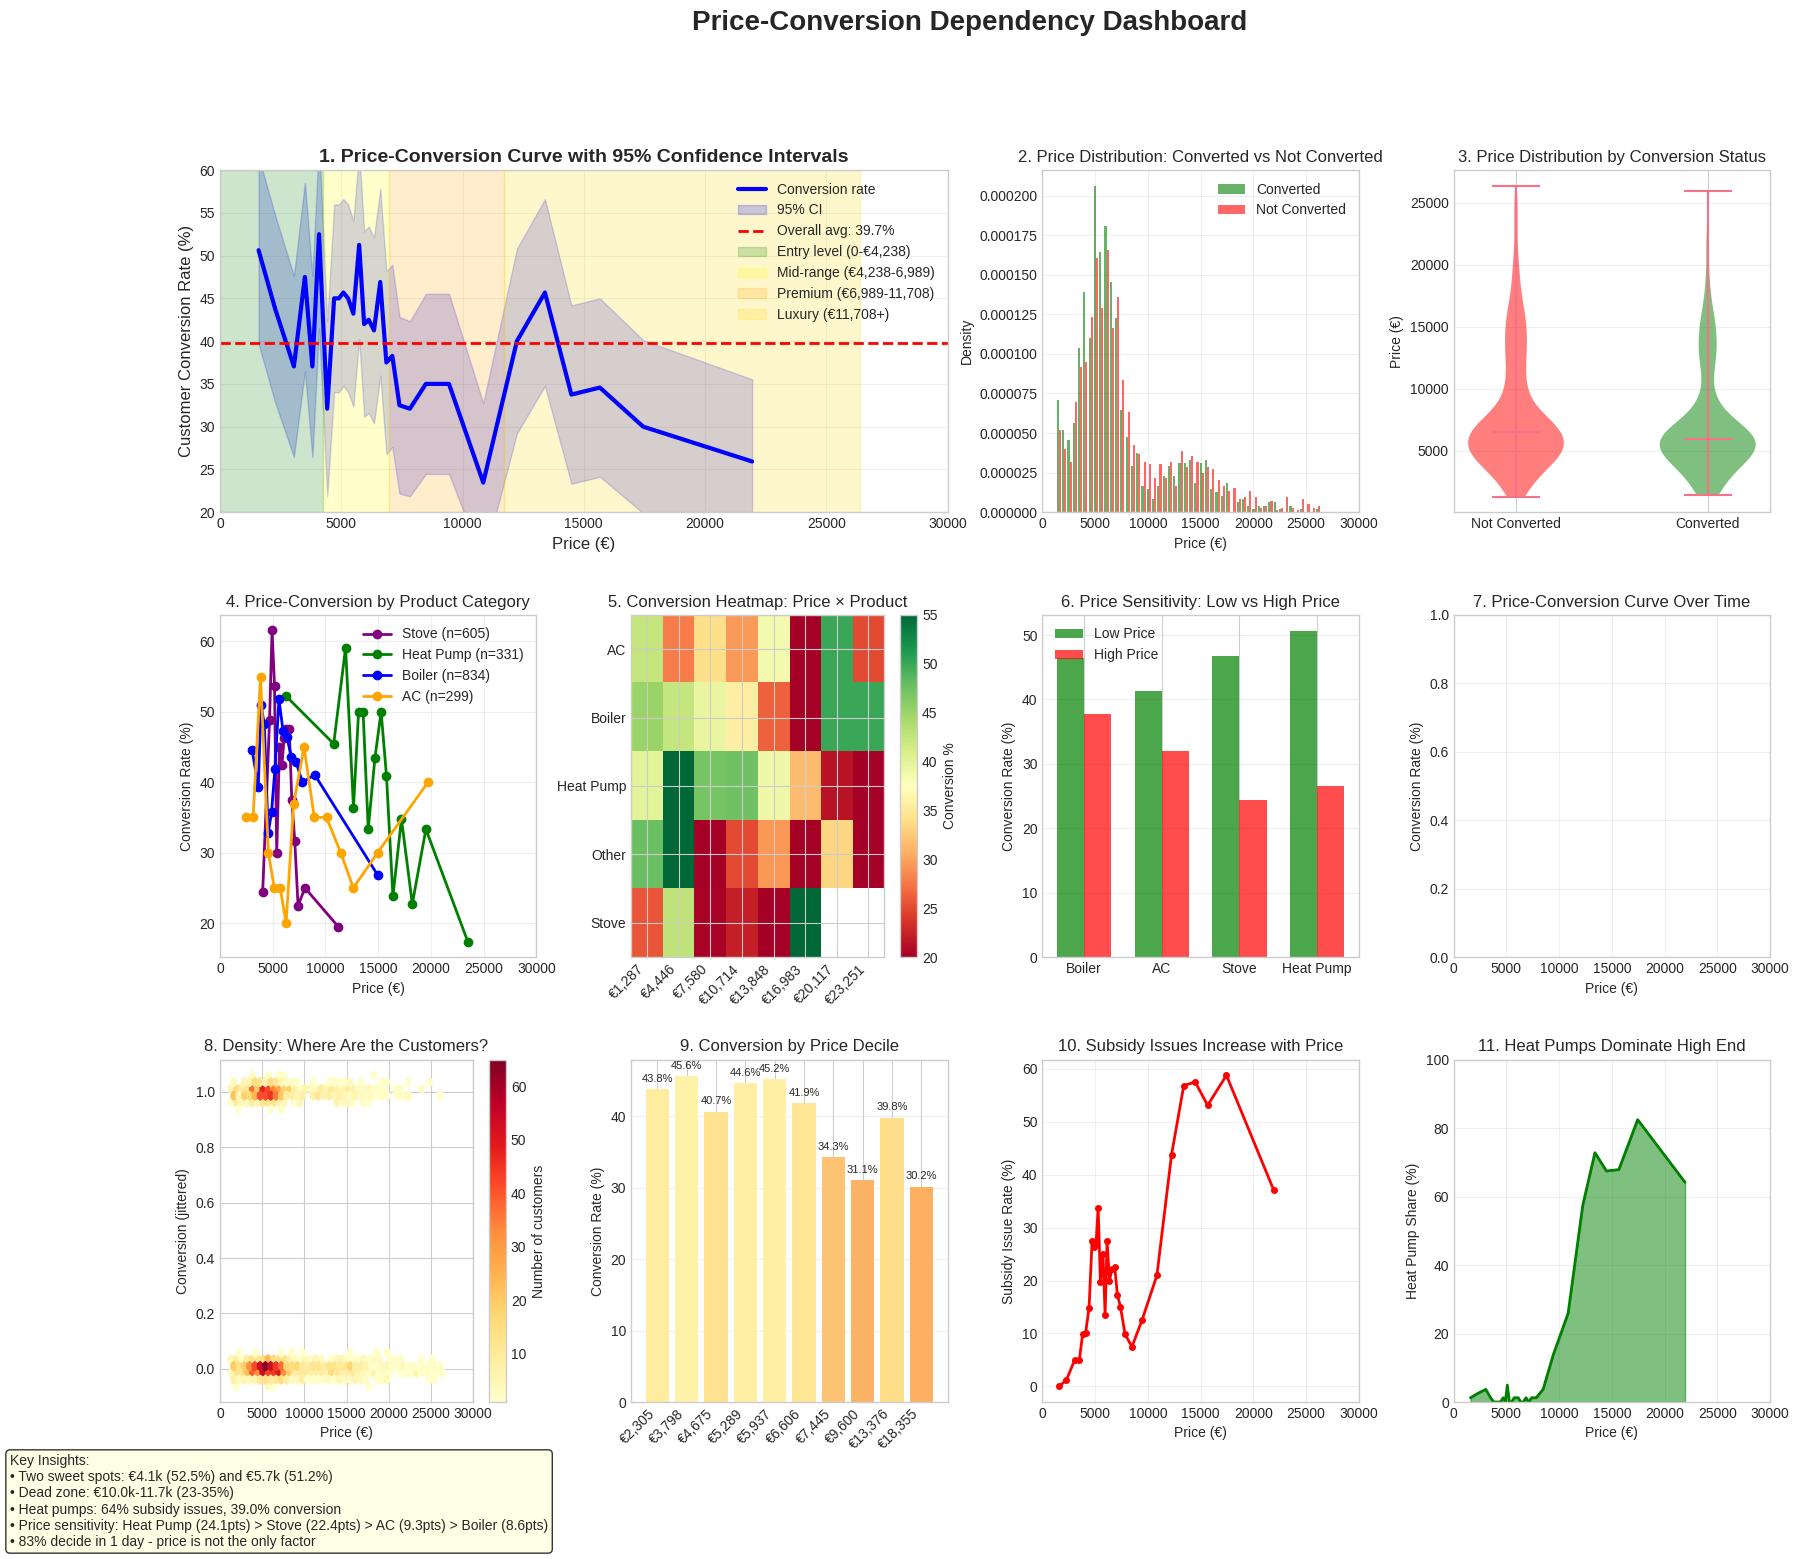

Actual product categories in data: ['AC', 'Boiler', 'Heat Pump', 'Other', 'Stove']


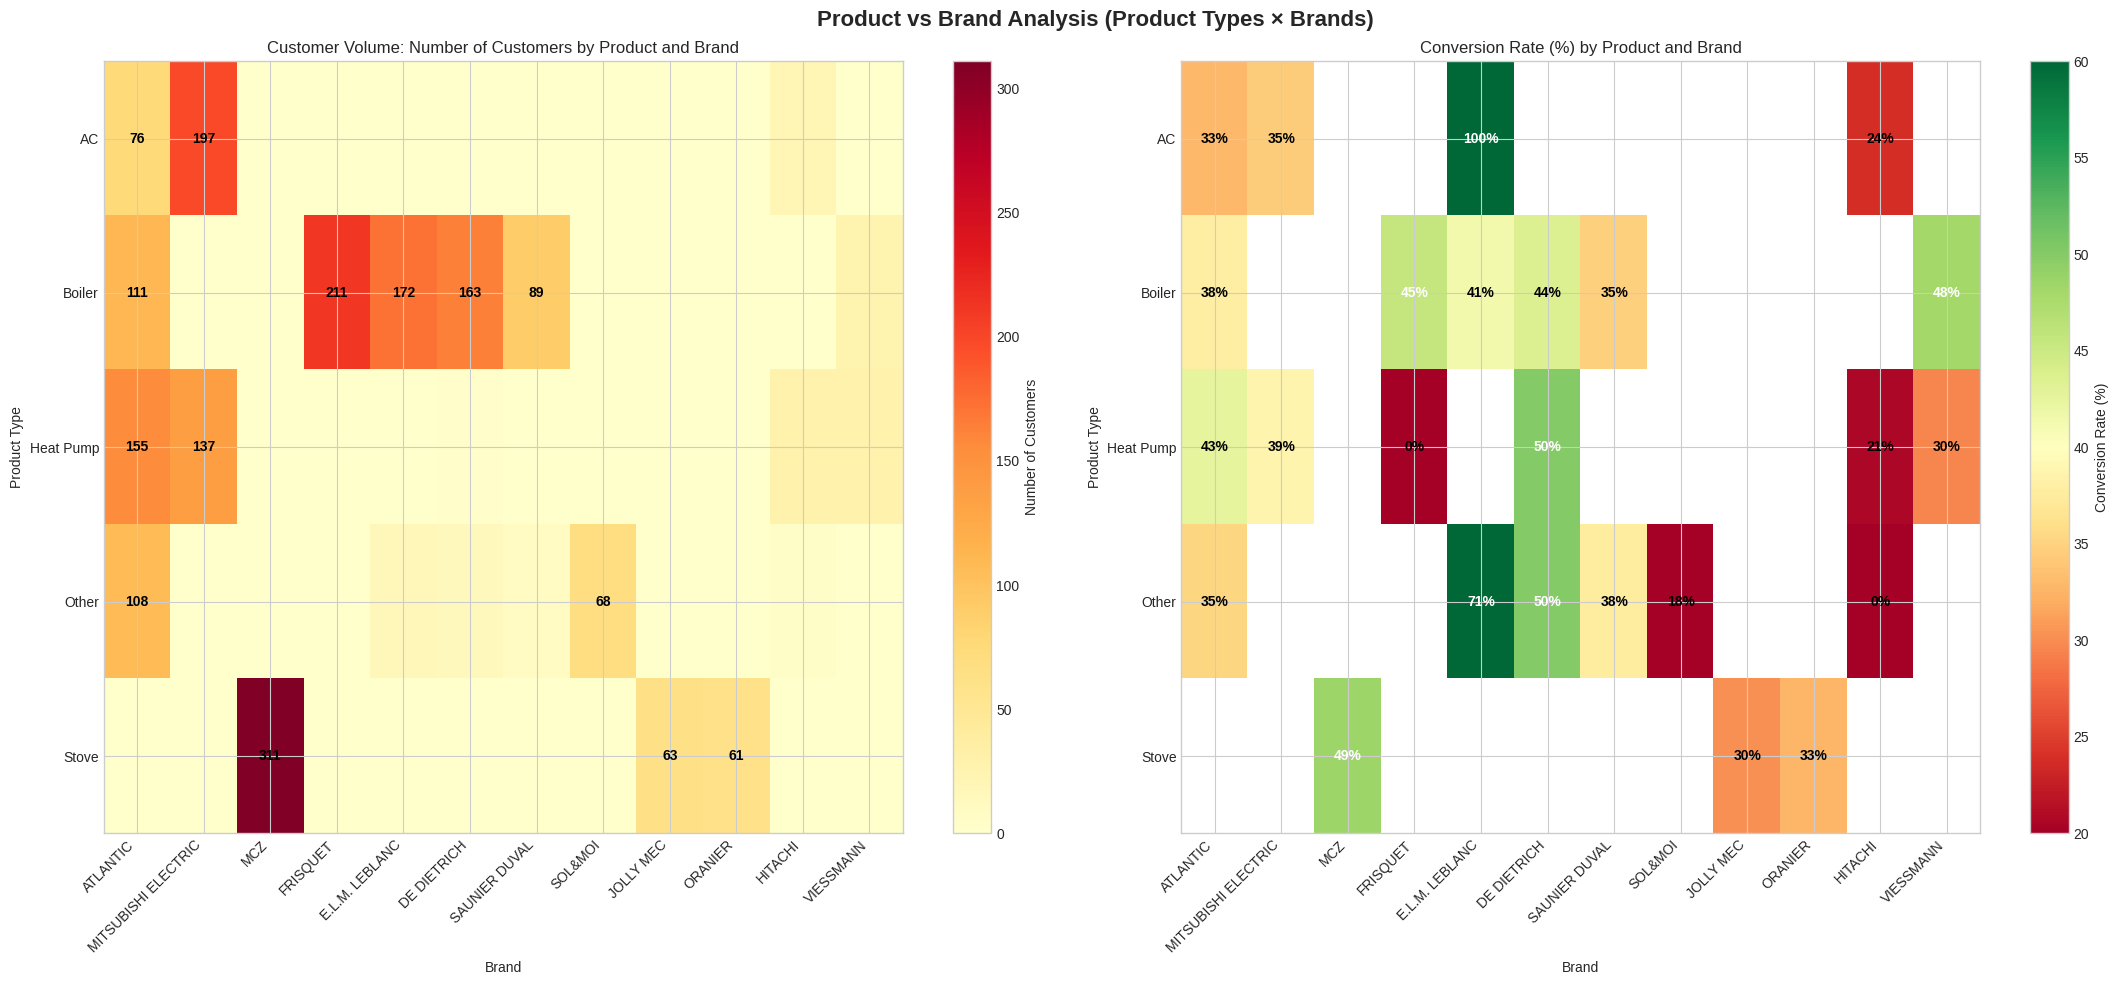


PRODUCT × BRAND ANALYSIS

📊 CUSTOMER VOLUME (Number of Customers):
--------------------------------------------------------------------------------
main_brand               ATLANTIC  MITSUBISHI ELECTRIC  MCZ  FRISQUET  E.L.M. LEBLANC  DE DIETRICH  SAUNIER DUVAL  SOL&MOI  JOLLY MEC  ORANIER  HITACHI  VIESSMANN
main_equipment_category                                                                                                                                           
AC                             76                  197    0         0               1            0              0        0          0        0       21          0
Boiler                        111                    0    0       211             172          163             89        0          0        0        0         25
Heat Pump                     155                  137    0         1               0            2              0        0          0        0       29         27
Other                         108   

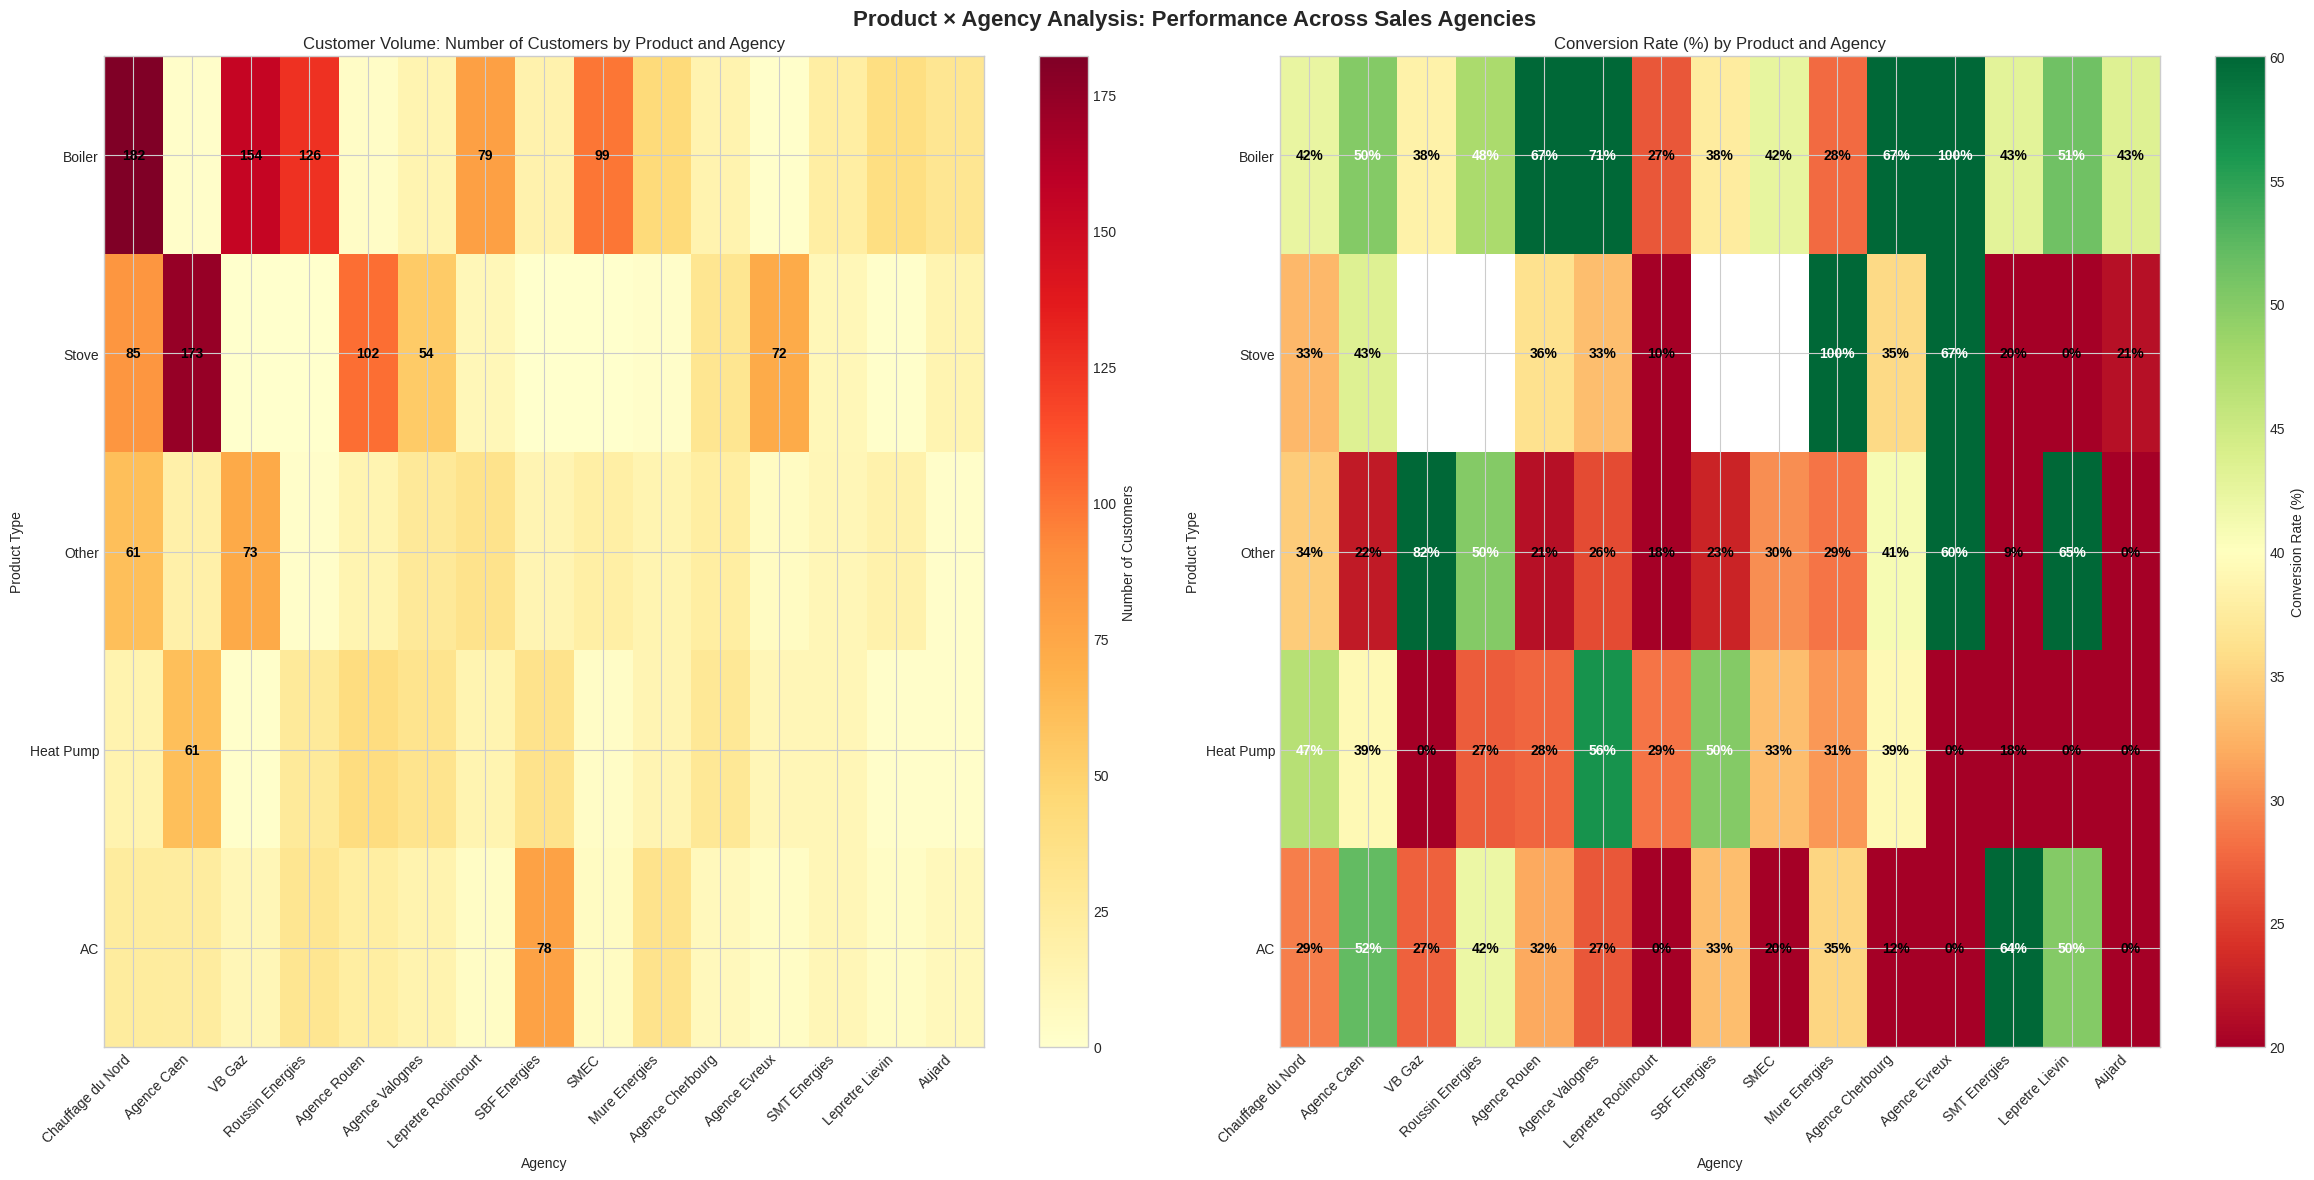


PRODUCT × AGENCY ANALYSIS

📊 CUSTOMER VOLUME BY PRODUCT AND AGENCY:
----------------------------------------------------------------------------------------------------
main_agency              Chauffage du Nord  Agence Caen  VB Gaz  Roussin Energies  Agence Rouen  Agence Valognes  Lepretre Roclincourt  SBF Energies  SMEC  Mure Energies  Agence Cherbourg  Agence Evreux  SMT Energies  Lepretre Lievin  Aujard
main_equipment_category                                                                                                                                                                                                                          
Boiler                                 182            2     154               126             3               14                    79            16    99             43                15              1            21               39      30
Stove                                   85          173       0                 0           102         

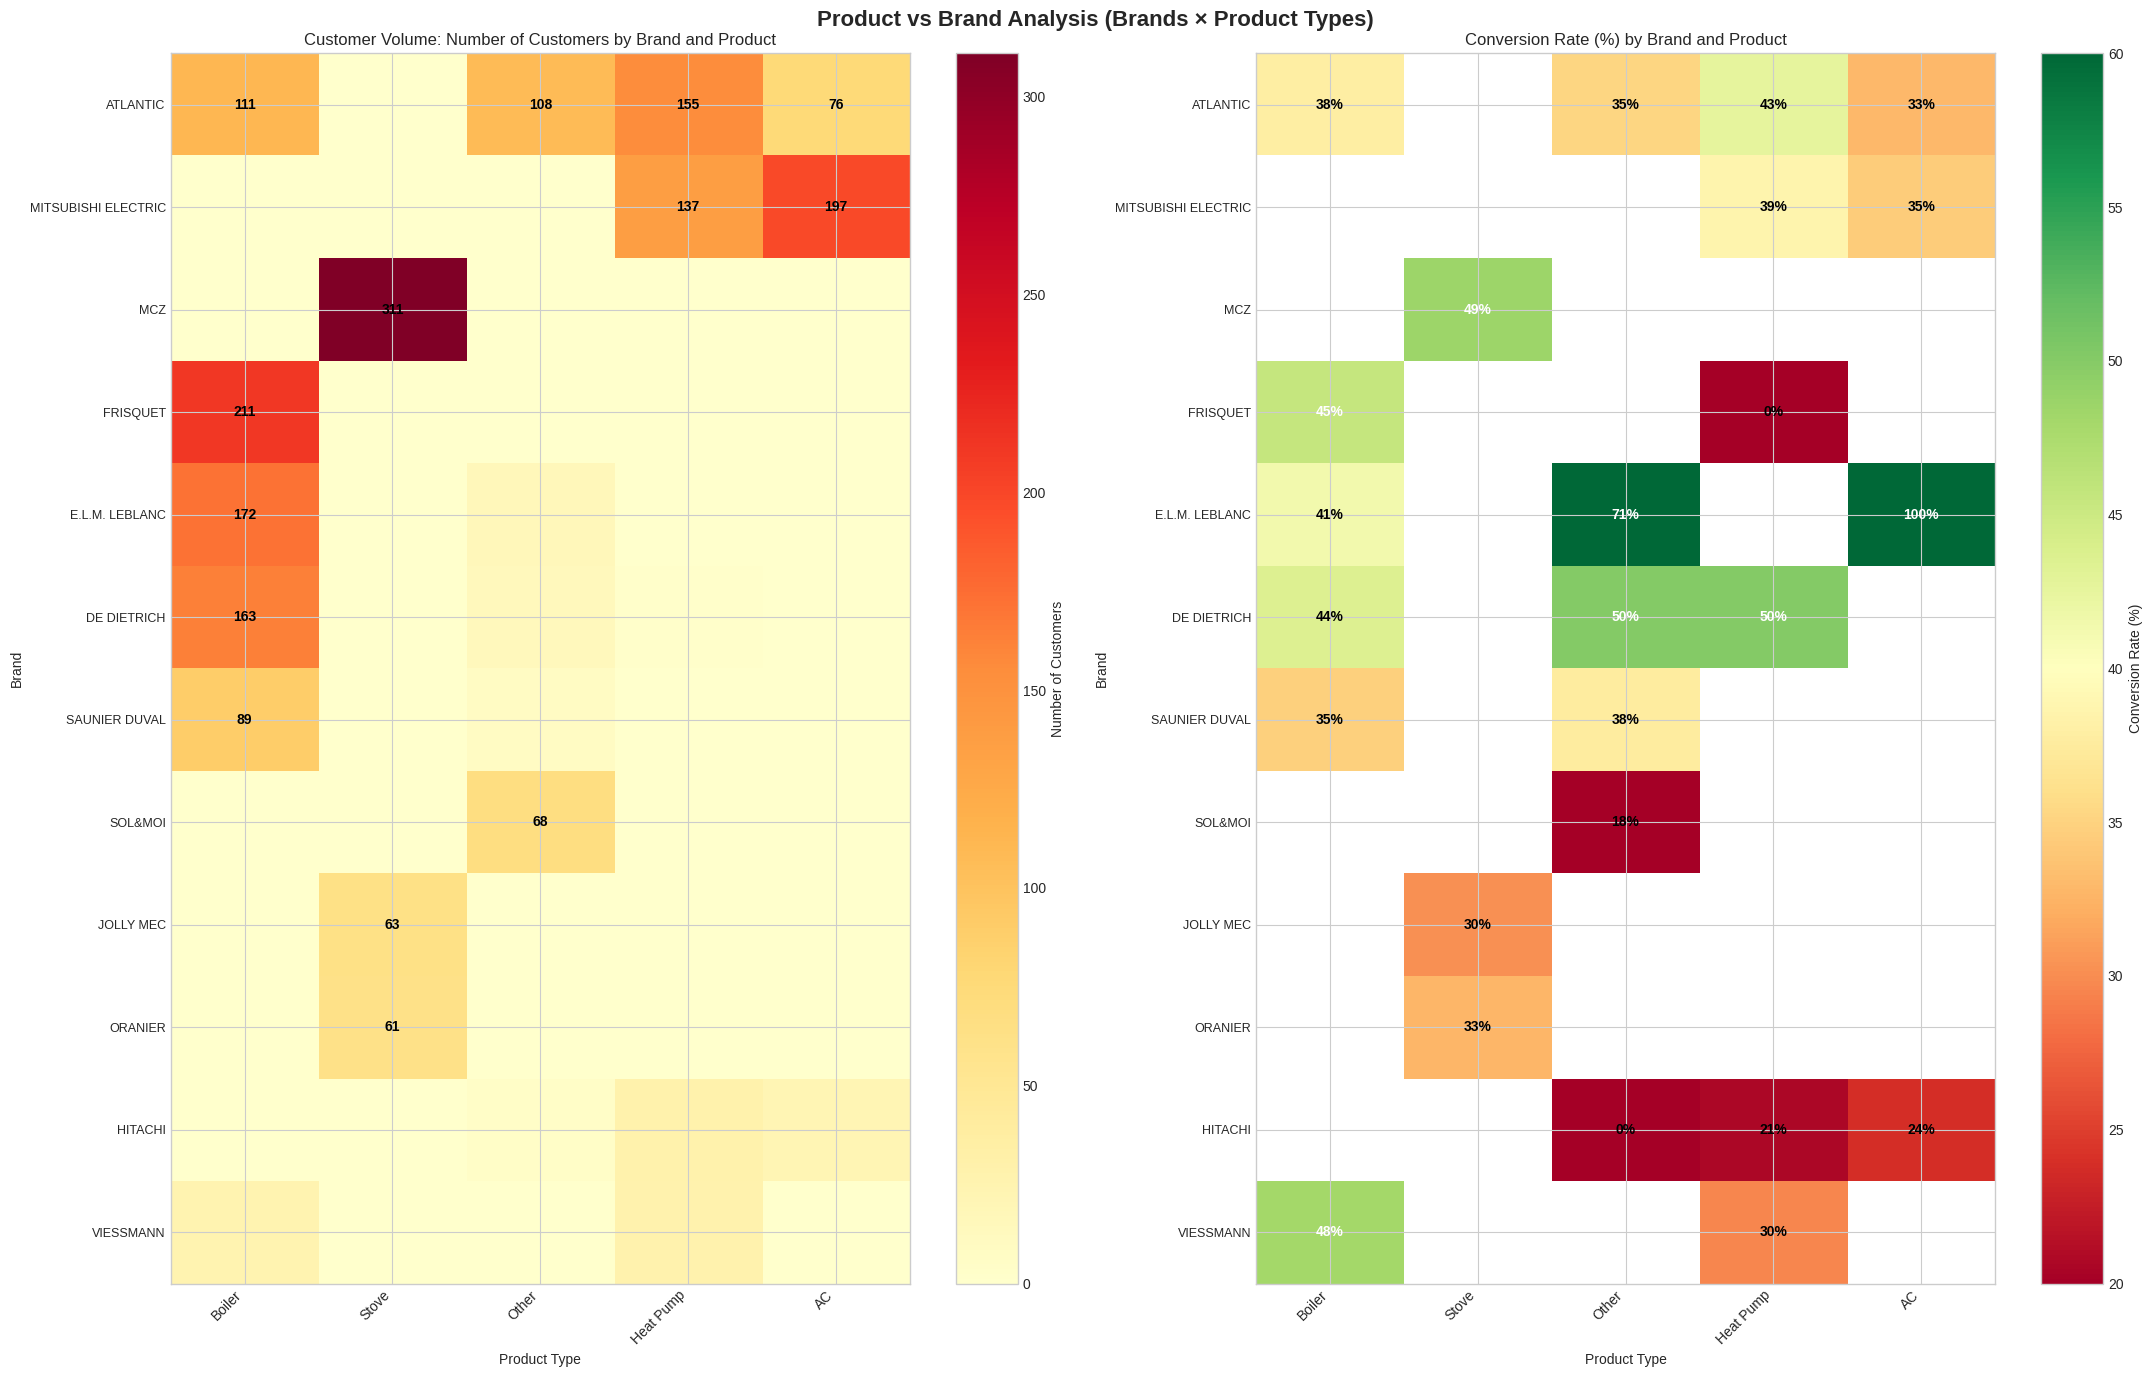


BRAND × PRODUCT ANALYSIS (Swapped Axes)

📊 CUSTOMER VOLUME (Number of Customers):
--------------------------------------------------------------------------------
main_equipment_category  Boiler  Stove  Other  Heat Pump   AC
main_brand                                                   
ATLANTIC                    111      0    108        155   76
MITSUBISHI ELECTRIC           0      0      0        137  197
MCZ                           0    311      0          0    0
FRISQUET                    211      0      0          1    0
E.L.M. LEBLANC              172      0     17          0    1
DE DIETRICH                 163      0     14          2    0
SAUNIER DUVAL                89      0      8          0    0
SOL&MOI                       0      0     68          0    0
JOLLY MEC                     0     63      0          0    0
ORANIER                       0     61      0          0    0
HITACHI                       0      0      4         29   21
VIESSMANN                    2

(main_equipment_category  Boiler  Stove  Other  Heat Pump   AC
 main_brand                                                   
 ATLANTIC                    111      0    108        155   76
 MITSUBISHI ELECTRIC           0      0      0        137  197
 MCZ                           0    311      0          0    0
 FRISQUET                    211      0      0          1    0
 E.L.M. LEBLANC              172      0     17          0    1
 DE DIETRICH                 163      0     14          2    0
 SAUNIER DUVAL                89      0      8          0    0
 SOL&MOI                       0      0     68          0    0
 JOLLY MEC                     0     63      0          0    0
 ORANIER                       0     61      0          0    0
 HITACHI                       0      0      4         29   21
 VIESSMANN                    25      0      0         27    0,
 main_equipment_category     Boiler      Stove      Other  Heat Pump  \
 main_brand                                  

In [6]:
conv_no_issue, conv_with_issue = report_customer_conversion_by_subsidy_issue_status(customers)
report_customer_metrics_by_subsidy_issue_status(customers)
visualize_conversion_by_subsidy_issues(customers, conv_no_issue, conv_with_issue)
visualize_policy_suspension_impact(customers, price_var='max_out_of_pocket')

top_products, no_issue_pct, issue_pct = report_customer_subsidy_issues_by_product(customers)
visualize_customer_subsidy_issues_by_product(customers, top_products, no_issue_pct, issue_pct)

visualize_conversion_by_price_sweet_spots(customers, price_var='max_out_of_pocket')
visualize_conversion_by_price_sweet_spots_variant(customers, price_var='max_out_of_pocket')
report_product_conversion_by_price_quartile(customers)
visualize_conversion_by_equipment_category_price(customers, price_var='max_out_of_pocket')
visualise_conversion_by_brand_price(customers, price_var='max_out_of_pocket')
show_two_panel_conversion_by_brand_price(customers, price_var='max_out_of_pocket')
visualize_conversion_by_equipment_type_brand_price(customers, price_var='max_out_of_pocket')

visualize_conversion_by_season(customers, price_var='max_out_of_pocket')
visualize_regional_seasonality(customers, price_var='max_out_of_pocket')

visualize_conversion_by_year(customers, price_var='max_out_of_pocket')
report_best_and_worst_months(customers, price_var='max_out_of_pocket')
show_conversion_by_price_over_time(customers, price_var='max_out_of_pocket')
overlay_all_years_on_one_plot(customers, price_var='max_out_of_pocket')
visualize_conversion_by_prices_sweet_spot_shift(customers, price_var='max_out_of_pocket')
visualize_decision_times(customers, price_var='max_out_of_pocket')
show_product_type_price_conversion_heatmap(customers, price_var='max_out_of_pocket')
show_decision_time_dashboard(customers, price_var='max_out_of_pocket')

visualise_heat_pump_performance(customers, price_var='max_out_of_pocket')

show_conversion_by_price_dashboard(customers, price_var='max_out_of_pocket')

show_product_type_by_brand_heatmap(customers)
show_product_type_by_agency_heatmap(customers)
show_brand_by_product_type_heatmap(customers)

In [10]:
import ipynbname
import subprocess
import os
import sys

def export_notebook_to_pdf(overwrite=True, verbose=True):
    """
    Export current notebook to PDF with overwrite control
    
    Args:
        overwrite (bool): If True, overwrite existing PDF file
        verbose (bool): If True, print progress messages
    
    Returns:
        bool: True if successful, False otherwise
    """
    try:
        # Get notebook path
        notebook_path = ipynbname.path()
        notebook_path_str = str(notebook_path)
        pdf_path = notebook_path_str.replace('.ipynb', '.pdf')
        
        if verbose:
            print(f"📓 Notebook: {notebook_path.name}")
            print(f"📄 PDF path: {pdf_path}")
        
        # Check if PDF exists
        if os.path.exists(pdf_path):
            if overwrite:
                if verbose:
                    print(f"🗑️ Removing existing PDF: {pdf_path}")
                os.remove(pdf_path)
            else:
                if verbose:
                    print(f"⚠️ PDF already exists and overwrite=False")
                return False
        
        # Convert to PDF
        if verbose:
            print("🔄 Converting to PDF...")
        
        result = subprocess.run([
            'jupyter', 'nbconvert', '--to', 'pdf',
            '--no-prompt',  # Suppress input prompts
            notebook_path_str
        ], capture_output=True, text=True)
        
        if result.returncode == 0:
            if verbose:
                print(f"✅ PDF saved: {pdf_path}")
            return True
        else:
            if verbose:
                print(f"❌ Conversion failed:")
                print(result.stderr)
            return False
            
    except Exception as e:
        if verbose:
            print(f"❌ Error: {e}")
        return False

# Use the function
if __name__ == "__main__":
    # Overwrite existing PDF
    export_notebook_to_pdf(overwrite=True)
    
    # Or create new version without overwriting
    # export_notebook_to_pdf(overwrite=False)export_full_notebook_to_pdf()

❌ Error: Can't identify the notebook path.


In [11]:
# Just hardcode your notebook name
notebook_name = "your_notebook_name.ipynb"  # Change this!

import subprocess
import os

pdf_path = notebook_name.replace('.ipynb', '.pdf')
if os.path.exists(pdf_path):
    os.remove(pdf_path)
    
subprocess.run(['jupyter', 'nbconvert', '--to', 'pdf', '--no-prompt', "_eda_price_2025_Q1.ipynb"])

[NbConvertApp] Converting notebook _eda_price_2025_Q1.ipynb to pdf
[NbConvertApp] Support files will be in _eda_price_2025_Q1_files/
[NbConvertApp] Making directory ./_eda_price_2025_Q1_files
[NbConvertApp] Writing 89995 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 2408654 bytes to _eda_price_2025_Q1.pdf


CompletedProcess(args=['jupyter', 'nbconvert', '--to', 'pdf', '--no-prompt', '_eda_price_2025_Q1.ipynb'], returncode=0)